Aqui va todo de lo que estoy seguro de usar

In [1]:
from limpio import *
import numpy as np
from sklearn.preprocessing import RobustScaler
from keras.callbacks import EarlyStopping
import torch.nn as nn
import torch
import pandas as pd


In [2]:
asset_list = ["bp1", "cl1", "es1", "gc1"]
ASSET = "es1"
MINUTES = 60
RETURN_HORIZON_MIN  = MINUTES * 2

Dataset 'bp1' imported with 4194013 rows
Limpieza bp1 completada. Filas restantes: 4110604


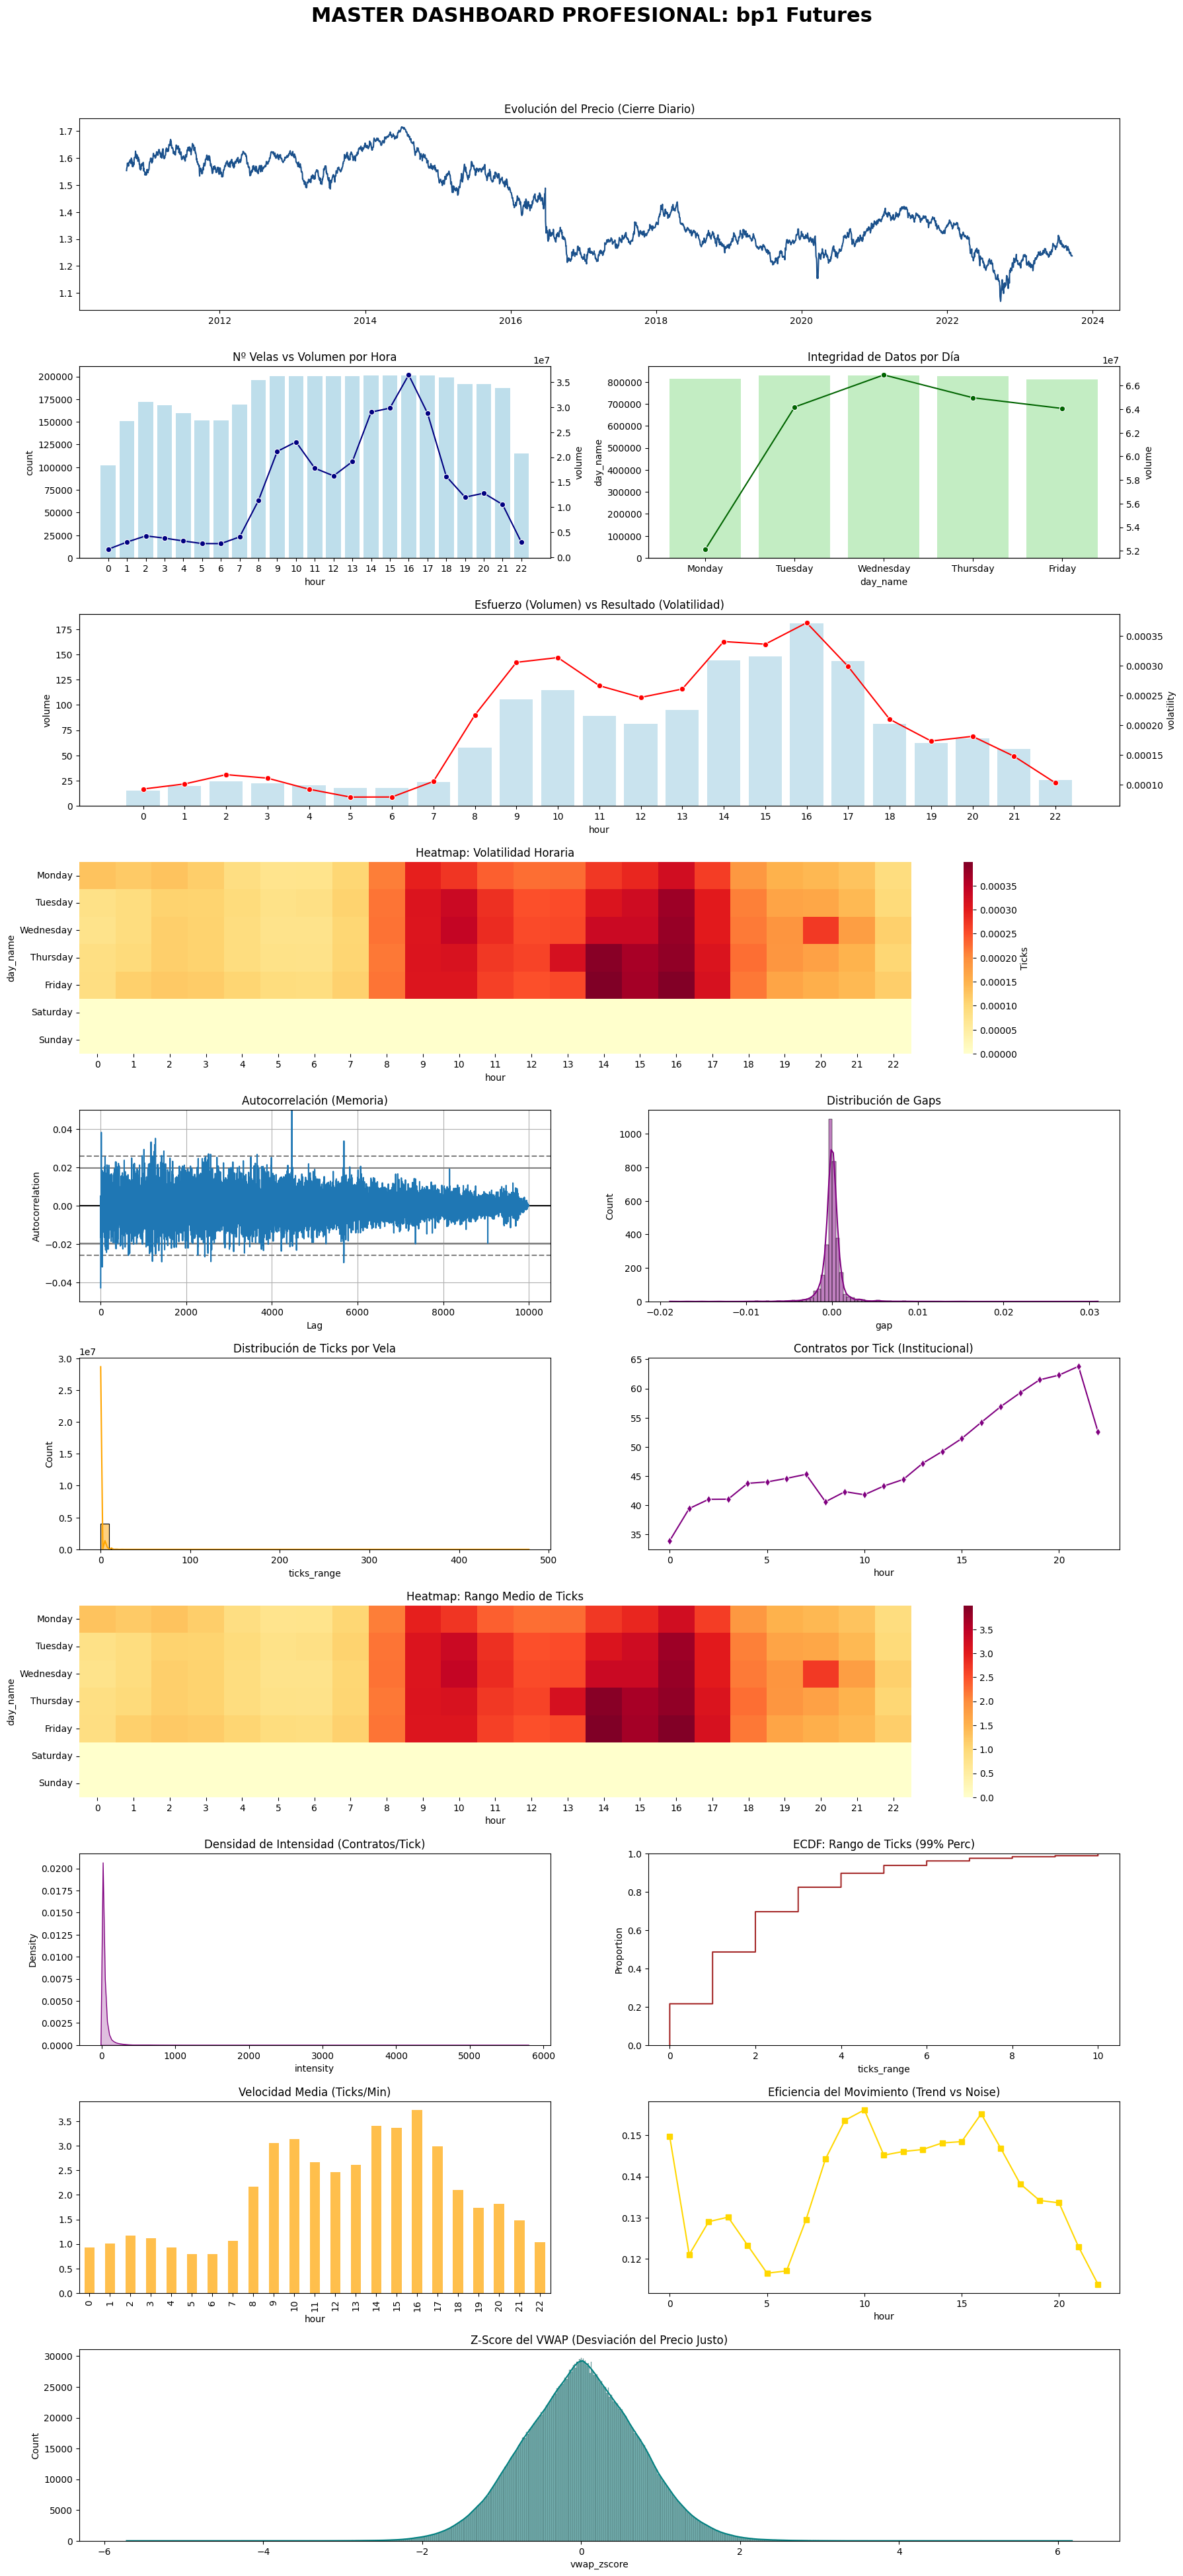

In [5]:
ASSET = asset_list[0]
df_min, spec = import_dataset(asset=ASSET)
df_min_clean = clean(df_min, ASSET, break_hour=spec['break_start'])
plot_master_market_analysis(df_min_clean, asset_name=f"{ASSET} Futures", tick_size=spec['tick_size'])

Dataset 'cl1' imported with 4533107 rows
Limpieza cl1 completada. Filas restantes: 4415052


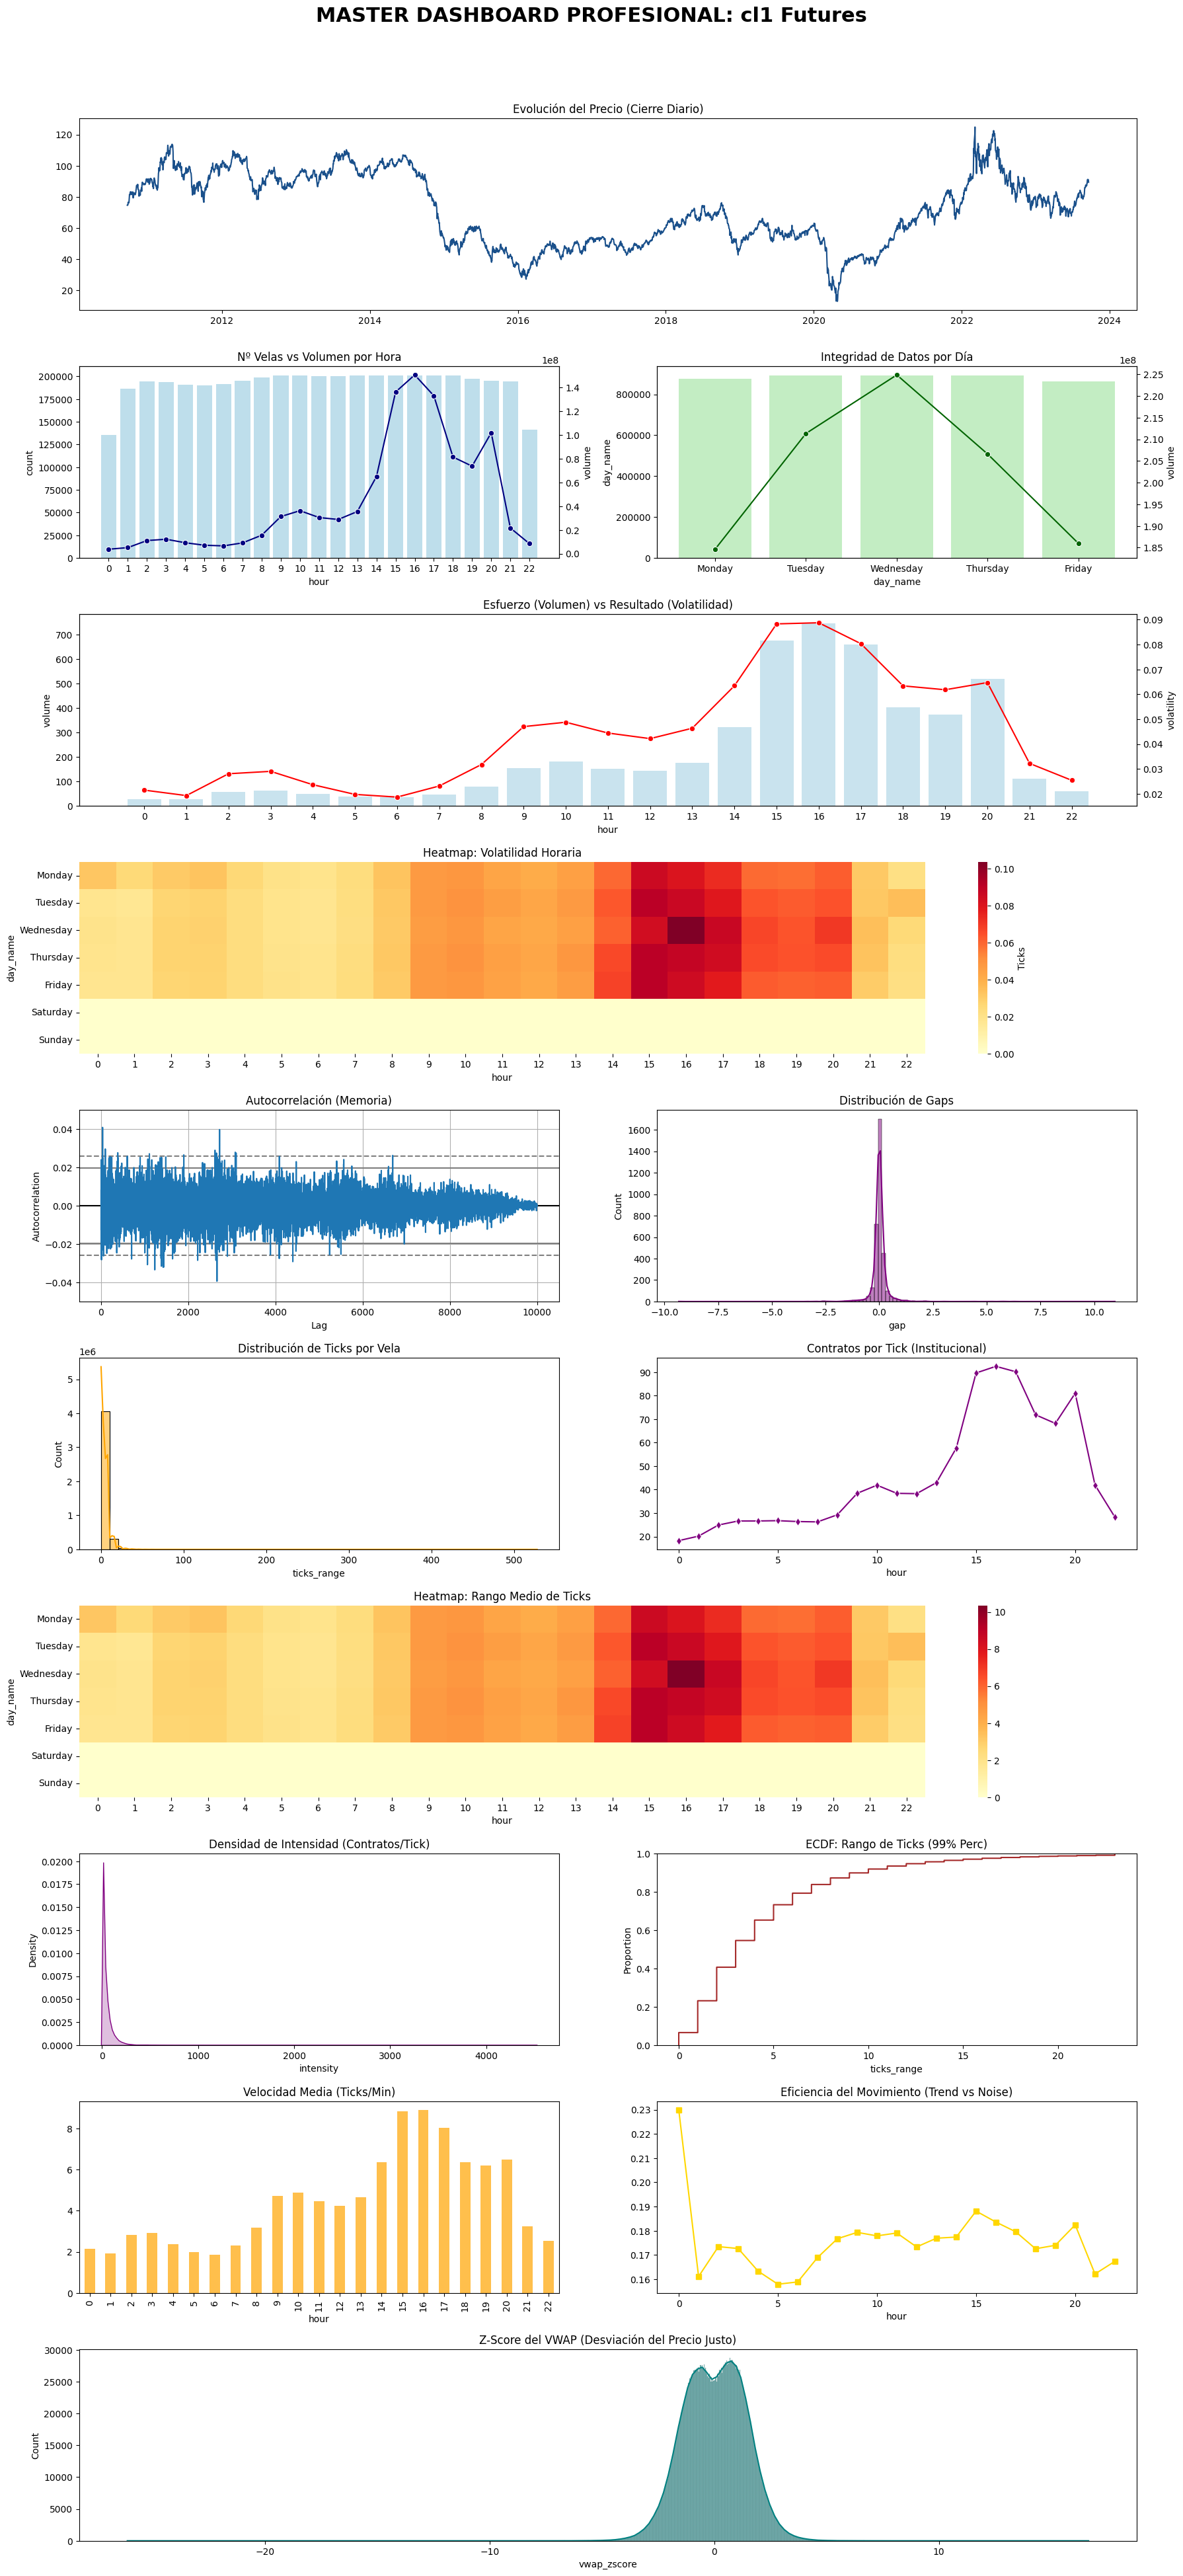

In [6]:
ASSET = asset_list[1]
df_min, spec = import_dataset(asset=ASSET)
df_min_clean = clean(df_min, ASSET, break_hour=spec['break_start'])
plot_master_market_analysis(df_min_clean, asset_name=f"{ASSET} Futures", tick_size=spec['tick_size'])

Dataset 'es1' imported with 2579332 rows
Limpieza es1 completada. Filas restantes: 2521092


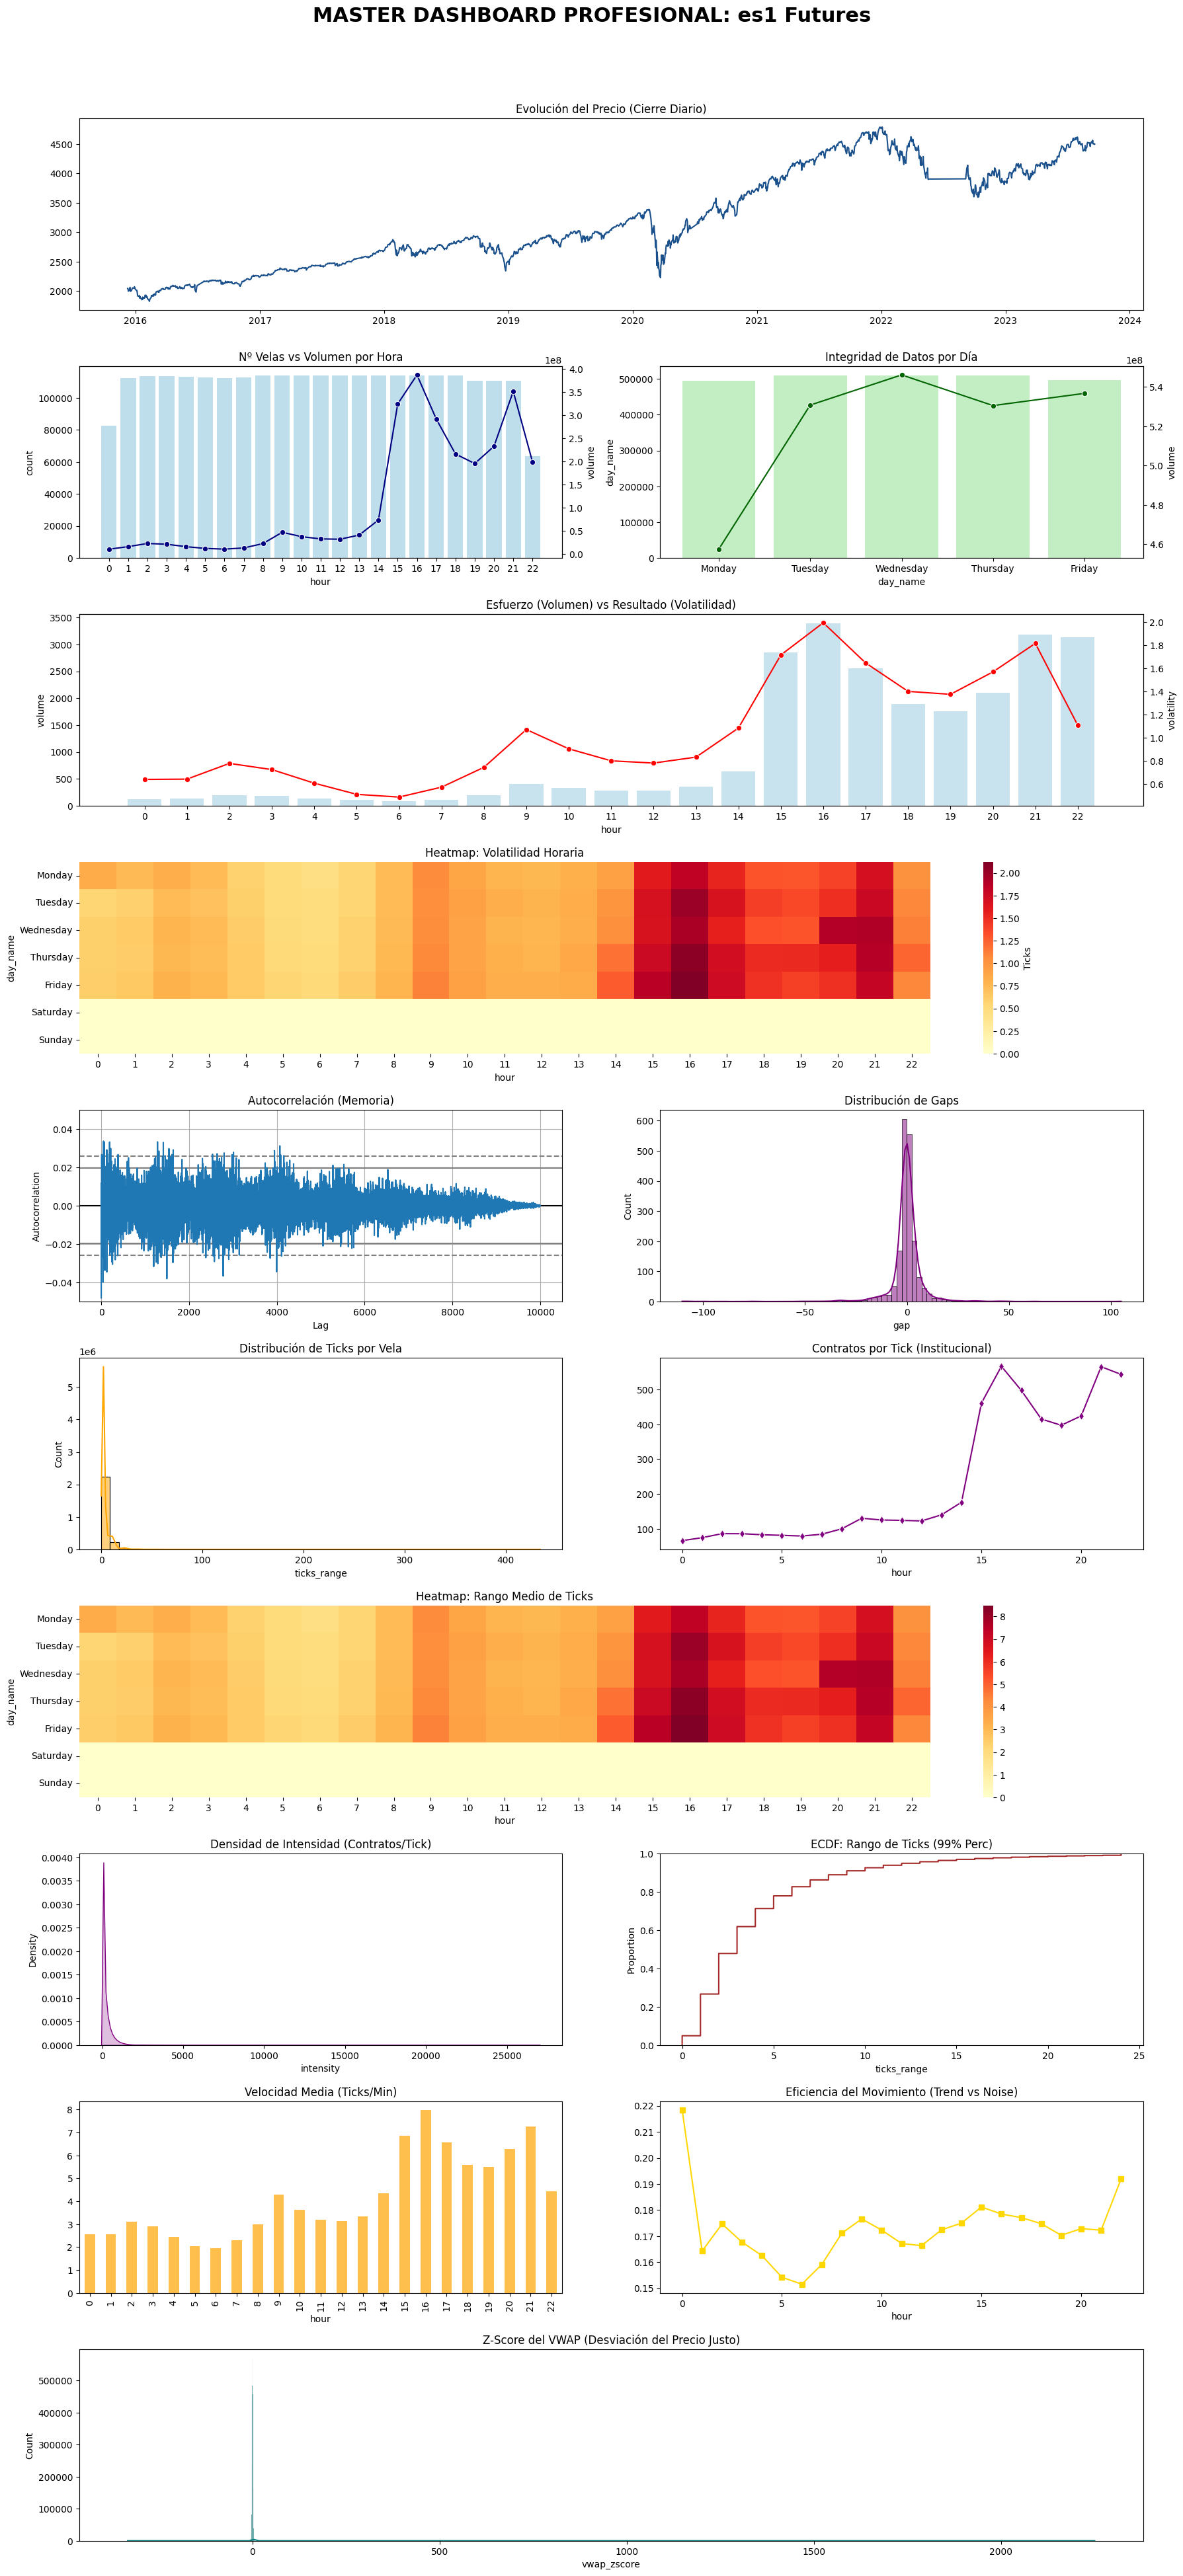

In [7]:
ASSET = asset_list[2]
df_min, spec = import_dataset(asset=ASSET)
df_min_clean = clean(df_min, ASSET, break_hour=spec['break_start'])
plot_master_market_analysis(df_min_clean, asset_name=f"{ASSET} Futures", tick_size=spec['tick_size'])

Dataset 'gc1' imported with 4565856 rows
Limpieza gc1 completada. Filas restantes: 4456388


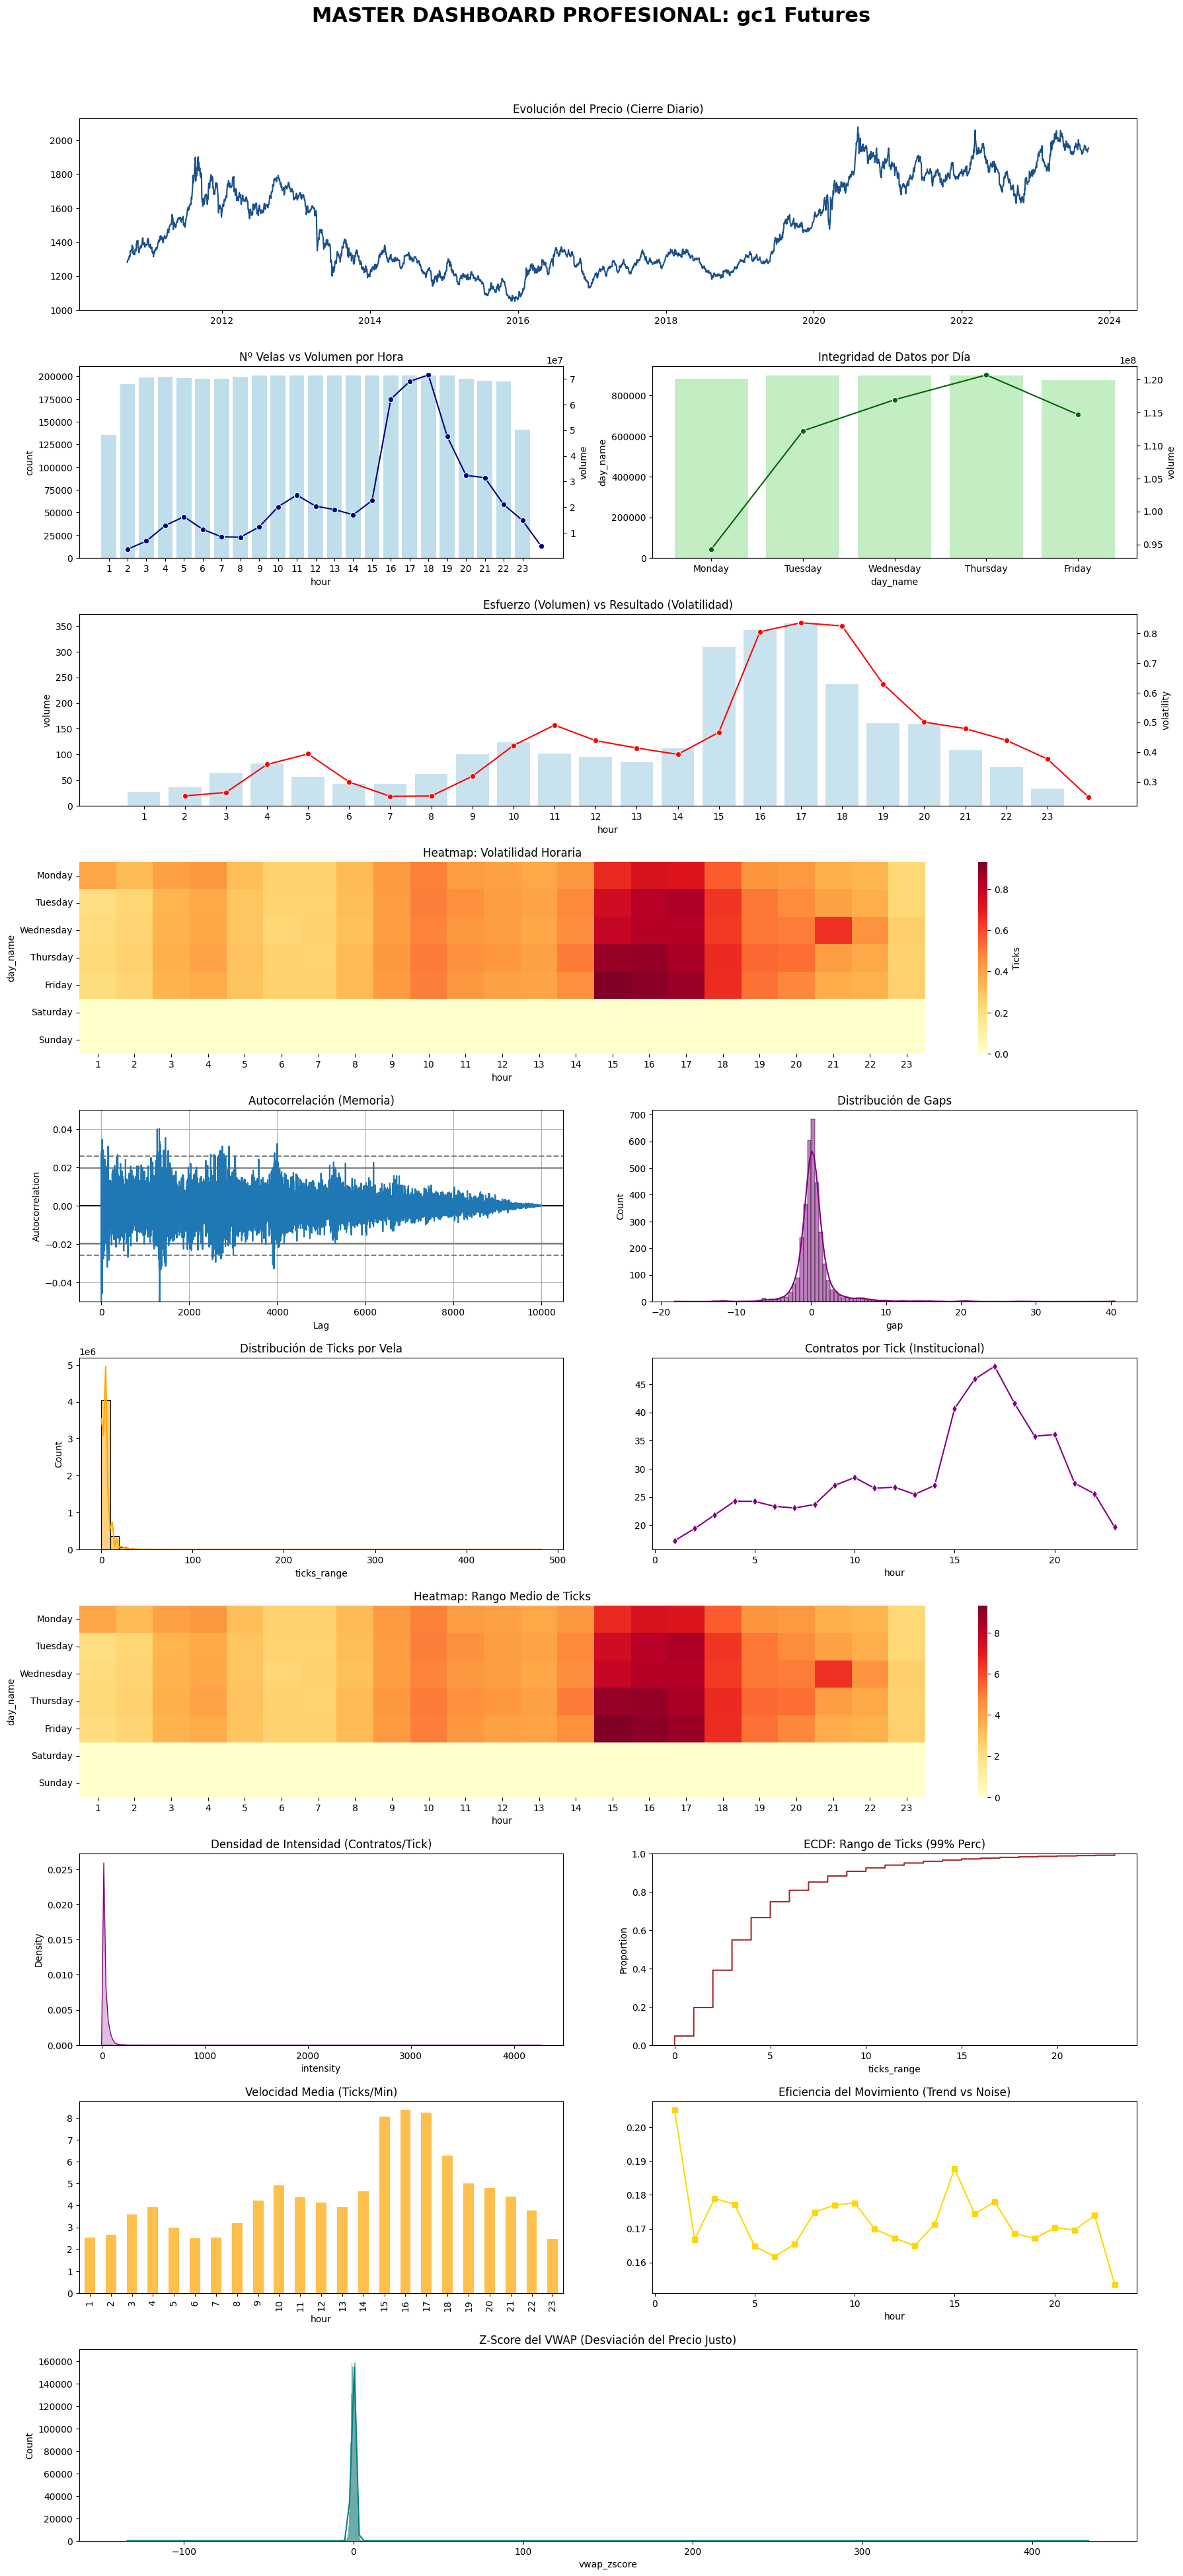

In [8]:
ASSET = asset_list[3]
df_min, spec = import_dataset(asset=ASSET)
df_min_clean = clean(df_min, ASSET, break_hour=spec['break_start'])
plot_master_market_analysis(df_min_clean, asset_name=f"{ASSET} Futures", tick_size=spec['tick_size'])

Dataset 'gc1' imported with 4565856 rows
Limpieza gc1 completada. Filas restantes: 4313900
✅ Agregado: 5min | Filas: 872080
✅ Agregado: 15min | Filas: 290814
✅ Agregado: 30min | Filas: 147073
✅ Agregado: 60min | Filas: 73576


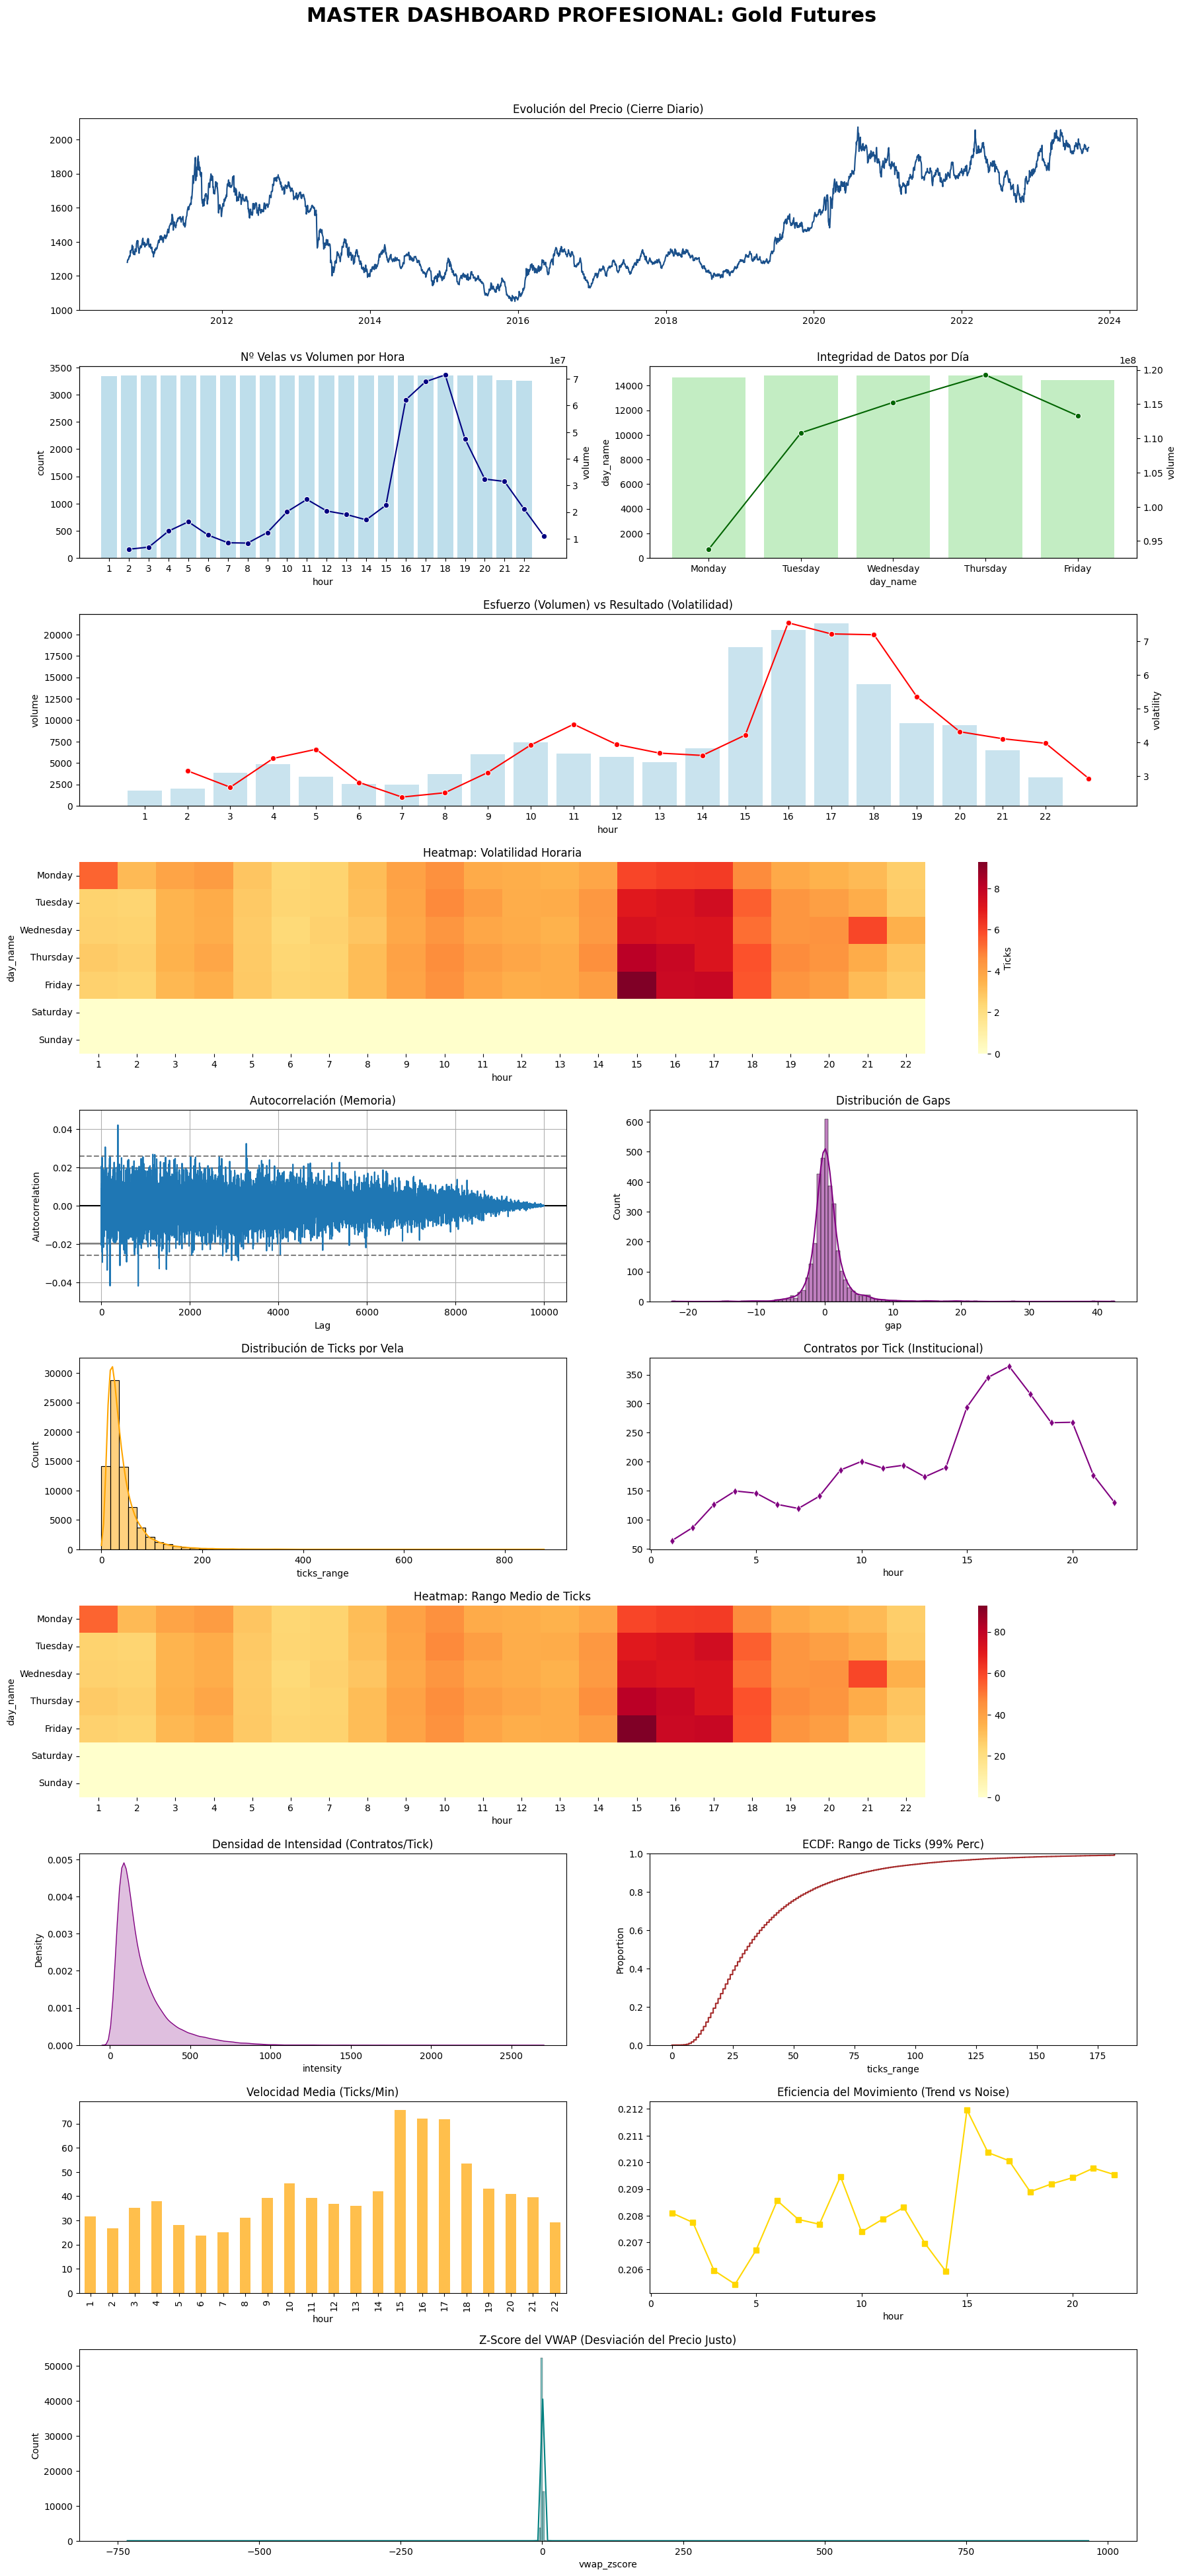

In [ ]:
df_min, spec = import_dataset(asset=ASSET)
df_min_clean = clean(df_min)
df_resampled = get_multitimeframe_data(df_min_clean)
plot_master_market_analysis(df_resampled[f'{MINUTES}min'], asset_name="Gold Futures", tick_size=spec['tick_size'])

In [4]:
df_cumulative = apply_cumulative_stats_to_dict(df_resampled)

✅ Procesados acumulados diarios para: 5min
✅ Procesados acumulados diarios para: 15min
✅ Procesados acumulados diarios para: 30min
✅ Procesados acumulados diarios para: 60min


In [5]:
df_final_dict = process_full_dictionary(df_cumulative, spec)

🚀 Features generadas para 5min: 92 columnas.
🚀 Features generadas para 15min: 92 columnas.
🚀 Features generadas para 30min: 92 columnas.
🚀 Features generadas para 60min: 92 columnas.


In [6]:
df_final_dict[f'{MINUTES}min'].iloc[0].to_dict()

{'datetime': Timestamp('2010-09-21 04:00:00'),
 'open': 1280.4,
 'high': 1280.5,
 'low': 1279.3,
 'close': 1280.0,
 'volume': 712,
 'openint': 0.0,
 'ticker': 'GC',
 'per': '60min',
 'trading_date': datetime.date(2010, 9, 21),
 'open_day': 1280.4,
 'high_cum': 1281.2,
 'low_cum': 1279.0,
 'volume_cum': 2827,
 'dist_to_high': 1.2000000000000455,
 'dist_to_low': 1.0,
 'step_sin': 0.8660254037844386,
 'step_cos': 0.5000000000000001,
 'dow_sin': 0.7818314824680298,
 'dow_cos': 0.6234898018587336,
 'is_london': 0,
 'is_ny': 0,
 'is_overlap': 0,
 'body_ticks': -4.0000000000009095,
 'range_ticks': 12.000000000000455,
 'upper_wick_ticks': 0.9999999999990905,
 'lower_wick_ticks': 7.000000000000455,
 'body_pct': 0.3333333330556187,
 'upper_wick_pct': 0.08333333326380993,
 'lower_wick_pct': 0.583333332847238,
 'close_location': 0.5833333284722381,
 'dist_high_cum_ticks': 12.000000000000455,
 'dist_low_cum_ticks': 10.0,
 'dist_open_day_ticks': -4.0000000000009095,
 'vol_per_tick': 54.7692307692288

In [7]:
FEATURE_COLUMNS = [
    # --- Ciclos y Tiempo ---
    'step_sin', 'step_cos', 'dow_sin', 'dow_cos',
    
    # --- Sesiones ---
    'is_london', 'is_ny', 'is_overlap',
    
    # --- Acción del Precio (Ticks) ---
    'body_pct', 'upper_wick_pct', 'lower_wick_pct', 'close_location',
    
    # --- Dinámica de Volumen ---
    'vol_per_tick', 'vol_vs_body', 'vol_weight_intraday',
    
    # --- Indicadores y Momentum ---
    'log_ret', 'rsi_14', 'volatility_20', 'efficiency_ratio',
    
    # --- Contexto y Valor ---
    'vwap_zscore', 'dist_sma_20_ticks', 'ticks_velocity',
    
    # --- Posición Diaria ---
    'dist_high_cum_ticks', 'dist_low_cum_ticks', 'dist_open_day_ticks',
    
        # Añade estas 3 a tu lista actual:
    'atr_norm',       # De features.py (Volatilidad relativa)
    'bb_percent_b',   # De features.py (Posición en bandas)
    'clv'             # De features.py (Presión de cierre)
]

TARGET_COLUMN = 'target_bin' # 1 si sube, 0 si baja/lateral

In [8]:
df_final_dict = audit_and_clean_dict(df_final_dict, FEATURE_COLUMNS)

--- 🔍 Auditando 5min ---
💎 Datos limpios. Sin NaNs.
-------------------------
--- 🔍 Auditando 15min ---
💎 Datos limpios. Sin NaNs.
-------------------------
--- 🔍 Auditando 30min ---
💎 Datos limpios. Sin NaNs.
-------------------------
--- 🔍 Auditando 60min ---
💎 Datos limpios. Sin NaNs.
-------------------------


In [9]:
result_torch, model, sc = run_walk_forward_pytorch_amp(df_final_dict[f'{MINUTES}min'], FEATURE_COLUMNS, train_size=5000, test_size=1000, step=500, lookback=24)

🖥️ Usando GPU: NVIDIA GeForce RTX 3060 Laptop GPU con AMP


e:\Futuro\MLAlgoTrading\TradingBots\limipio\limpio.py:1026: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_amp = GradScaler()
e:\Futuro\MLAlgoTrading\TradingBots\limipio\limpio.py:1063: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


✅ Ventana 2010-09-21 OK. Acc: 52.66%


e:\Futuro\MLAlgoTrading\TradingBots\limipio\limpio.py:1063: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


✅ Ventana 2010-10-20 OK. Acc: 52.25%


...

✅ Ventana 2022-01-03 OK. Acc: 52.66%


e:\Futuro\MLAlgoTrading\TradingBots\limipio\limpio.py:1063: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


✅ Ventana 2022-02-02 OK. Acc: 51.33%


e:\Futuro\MLAlgoTrading\TradingBots\limipio\limpio.py:1063: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


✅ Ventana 2022-03-04 OK. Acc: 52.25%


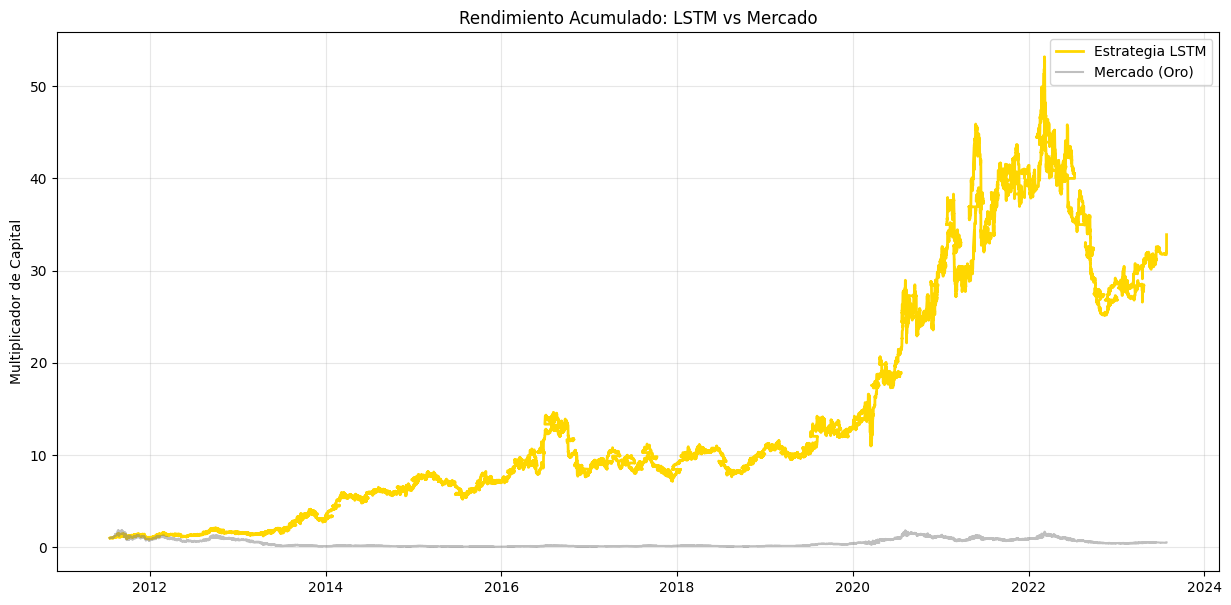

💰 Sharpe Ratio Estimado: 0.19
📈 Retorno Total Estrategia: 3288.51%


In [10]:
plot_trading_results(result_torch)

In [11]:
# Calculamos la volatilidad media (ATR simplificado) para que el umbral sea lógico
volatilidad_media = df_final_dict[f'{MINUTES}min']['target_ret_30m'].abs().mean()
print(f"Volatilidad media cada 30 min: {volatilidad_media:.5f}")

# Umbral: Solo queremos operar si el movimiento esperado es mayor que la media
threshold = volatilidad_media * 0.7

Volatilidad media cada 30 min: 0.00222


In [12]:
# Definir el umbral (ajustar según volatilidad)
# threshold = 0.0005 

def label_triple(ret):
    if ret > threshold:
        return 2 # Buy
    elif ret < -threshold:
        return 0 # Sell
    else:
        return 1 # Neutral

df_final_dict[f'{MINUTES}min']['target_triple'] = df_final_dict[f'{MINUTES}min']['target_ret_30m'].apply(label_triple)

# Verifica el balance de clases
print(df_final_dict[f'{MINUTES}min']['target_triple'].value_counts(normalize=True))

target_triple
1    0.532873
2    0.237340
0    0.229787
Name: proportion, dtype: float64


In [13]:
class GoldLSTM_Triple(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, dropout=0.3):
        super(GoldLSTM_Triple, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, 
                            batch_first=True, dropout=dropout)
        
        self.batch_norm = nn.BatchNorm1d(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 3) # Salida para: [Sell, Neutral, Buy]

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        
        out, _ = self.lstm(x, (h0, c0))
        out = out[:, -1, :] 
        
        out = self.batch_norm(out)
        out = self.fc1(out)
        out = self.relu(out)
        out = self.dropout(out)
        return self.fc2(out) # Retorna logits

In [14]:
class GoldLSTM_V2(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=1, dropout=0.2): # Más ligero
        super(GoldLSTM_V2, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 3) # Directo a las 3 clases

    def forward(self, x):
        # Usamos solo el último estado oculto
        _, (hn, _) = self.lstm(x)
        out = self.dropout(hn[-1])
        return self.fc(out)

In [15]:
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 1. Definir Pesos de Clase (Penalizamos más el fallo en Buy/Sell)
# Clase 0 (Sell): Peso 2.5 | Clase 1 (Neutral): Peso 1.0 | Clase 2 (Buy): Peso 2.5
class_weights = torch.tensor([2.5, 1.0, 2.5], dtype=torch.float32).to("cuda")

def run_walk_forward_triple_final(df, feature_cols, target_col='target_triple'):
    device = torch.device("cuda")
    scaler_amp = torch.amp.GradScaler('cuda')
    all_predictions = []
    
    # Parámetros óptimos para tu 3060
    # train_size=5000, test_size=1000, step=500, lookback=24
    train_size, test_size, step = 5000, 1000, 500
    lookback, epochs, batch_size = 24, 10, 512 # Subimos epochs y batch_size
    
    df_wf = df.copy().sort_values('datetime').reset_index(drop=True)
    
    for start in tqdm(range(0, len(df_wf) - train_size - test_size, step), desc="Training Triple"):
        # ... [Segmentación y Escalado RobustScaler igual que antes] ...
        end_train = start + train_size
        end_test = end_train + test_size
        
        # --- Preprocesado y Escalado ---
        train_df = df_wf.iloc[start:end_train].copy()
        test_df = df_wf.iloc[end_train:end_test].copy()
        
        sc = RobustScaler()
        train_df[feature_cols] = sc.fit_transform(train_df[feature_cols])
        test_df[feature_cols] = sc.transform(test_df[feature_cols])
        
        X_train, y_train = create_lstm_dataset(train_df, feature_cols, target_col, lookback)
        X_test, y_test = create_lstm_dataset(test_df, feature_cols, target_col, lookback)
        
        # Preparar Tensores
        X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
        y_train_t = torch.tensor(y_train, dtype=torch.long).to(device) # LONG para CrossEntropy
        X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
        
        loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
        
        # Modelo
        model = GoldLSTM_Triple(input_dim=len(feature_cols)).to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.0005)
        criterion = nn.CrossEntropyLoss(weight=class_weights) # <--- PESOS AQUÍ
        
        # Entrenamiento con AMP
        model.train()
        for epoch in range(epochs):
            for batch_X, batch_y in loader:
                optimizer.zero_grad()
                with torch.amp.autocast('cuda'):
                    outputs = model(batch_X)
                    loss = criterion(outputs, batch_y)
                scaler_amp.scale(loss).backward()
                scaler_amp.step(optimizer)
                scaler_amp.update()
        
        # Predicción
        model.eval()
        with torch.no_grad():
            logits = model(X_test_t)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)
            
        # ... [Guardar en DataFrame res_df como el anterior] ...
        res_df = pd.DataFrame({
            'datetime': df_wf['datetime'].iloc[end_train + lookback : end_test].values,
            'actual': y_test,
            'pred': preds,
            'prob_sell': probs[:, 0],
            'prob_neutral': probs[:, 1],
            'prob_buy': probs[:, 2],
            'ret_real': df_wf['target_ret_30m'].iloc[end_train + lookback : end_test].values
        })
        all_predictions.append(res_df)
        torch.cuda.empty_cache()
        print(f"✅ Ventana {df_wf['datetime'].iloc[start].date()} OK. Acc: {(preds == y_test).mean():.2%}")

    return pd.concat(all_predictions, ignore_index=True)

In [16]:
result_triple = run_walk_forward_triple_final(df_final_dict[f'{MINUTES}min'], FEATURE_COLUMNS)

Training Triple:   0%|          | 0/137 [00:00<?, ?it/s]

✅ Ventana 2010-09-21 OK. Acc: 40.47%
✅ Ventana 2010-10-20 OK. Acc: 41.70%
✅ Ventana 2010-11-18 OK. Acc: 38.83%
✅ Ventana 2010-12-17 OK. Acc: 37.81%
✅ Ventana 2011-01-18 OK. Acc: 35.35%
✅ Ventana 2011-02-16 OK. Acc: 35.35%
✅ Ventana 2011-03-17 OK. Acc: 40.37%
✅ Ventana 2011-04-15 OK. Acc: 38.93%
✅ Ventana 2011-05-17 OK. Acc: 43.55%
✅ Ventana 2011-06-15 OK. Acc: 40.68%
✅ Ventana 2011-07-15 OK. Acc: 39.45%
✅ Ventana 2011-08-15 OK. Acc: 42.11%
✅ Ventana 2011-09-13 OK. Acc: 48.16%
✅ Ventana 2011-10-12 OK. Acc: 45.39%
✅ Ventana 2011-11-10 OK. Acc: 42.73%
✅ Ventana 2011-12-09 OK. Acc: 44.88%
✅ Ventana 2012-01-11 OK. Acc: 48.98%
✅ Ventana 2012-02-09 OK. Acc: 51.23%
✅ Ventana 2012-03-12 OK. Acc: 50.51%
✅ Ventana 2012-04-11 OK. Acc: 54.61%
✅ Ventana 2012-05-10 OK. Acc: 50.20%
✅ Ventana 2012-06-08 OK. Acc: 42.83%
✅ Ventana 2012-07-09 OK. Acc: 44.67%
✅ Ventana 2012-08-07 OK. Acc: 38.32%
✅ Ventana 2012-09-05 OK. Acc: 36.27%
✅ Ventana 2012-10-04 OK. Acc: 36.78%
✅ Ventana 2012-11-02 OK. Acc: 38.32%
✅

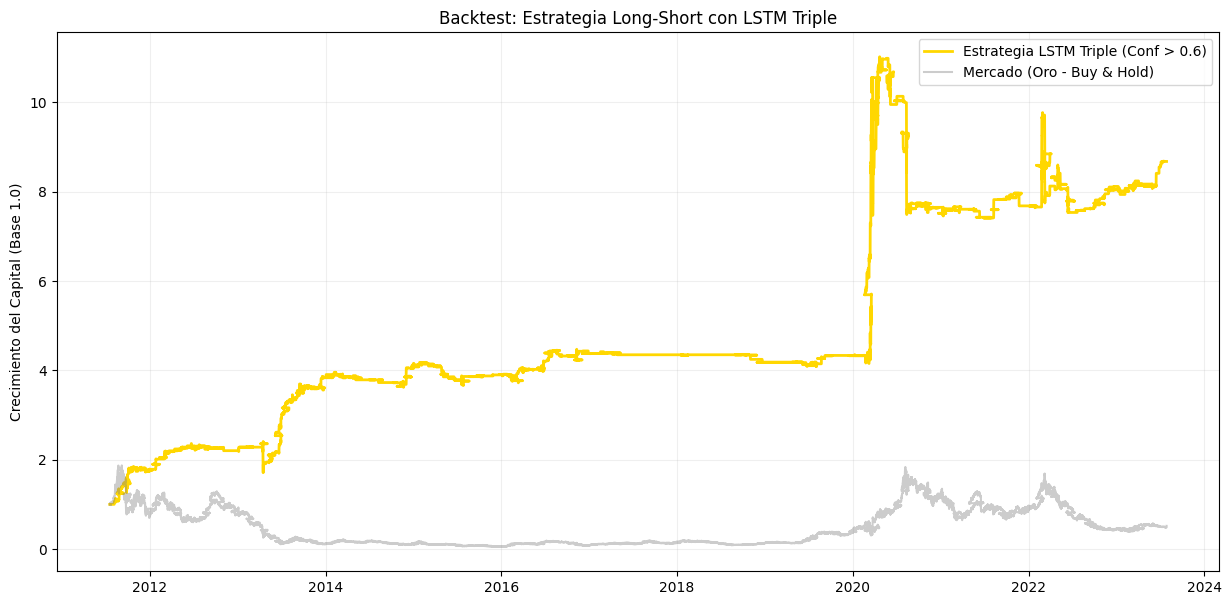

------------------------------
💰 NUEVO Sharpe Ratio: 1.61
📈 Retorno Total: 767.46%
🎯 Win Rate (de los trades): 55.68%
📊 Ratio de Operatividad: 2.92% (tiempo en mercado)
📉 Total de Trades: 3906 de 133712 velas
------------------------------


In [17]:
plot_triple_trading_results(result_triple, 0.6)

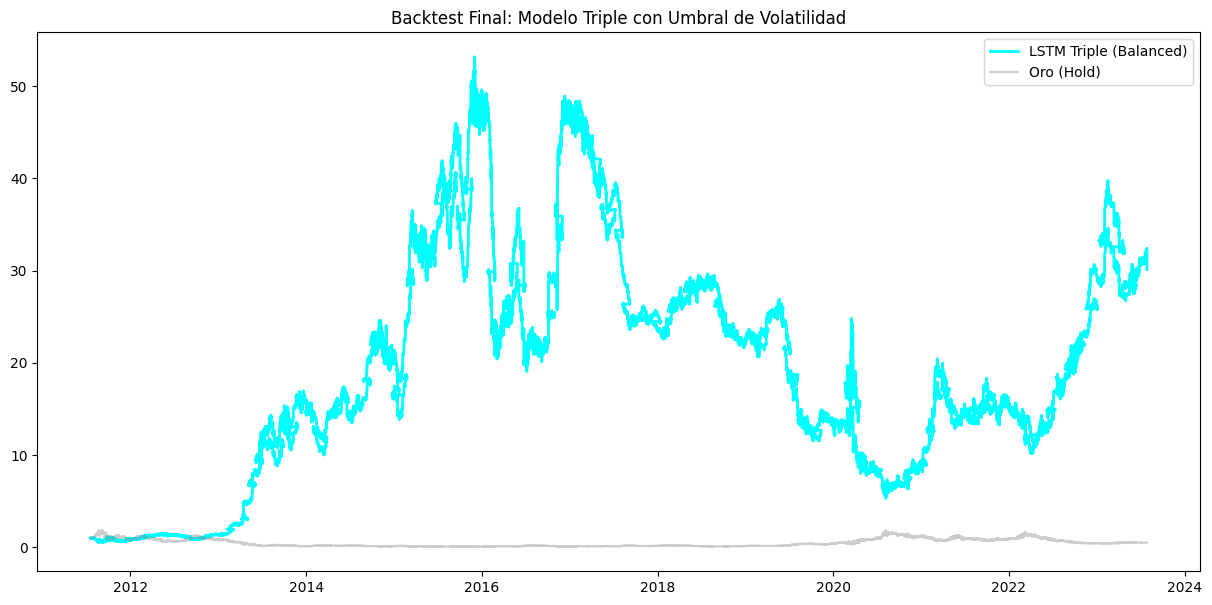

💰 Sharpe Ratio Esperado: 1.04


In [18]:
plot_triple_final_comparison(result_triple)

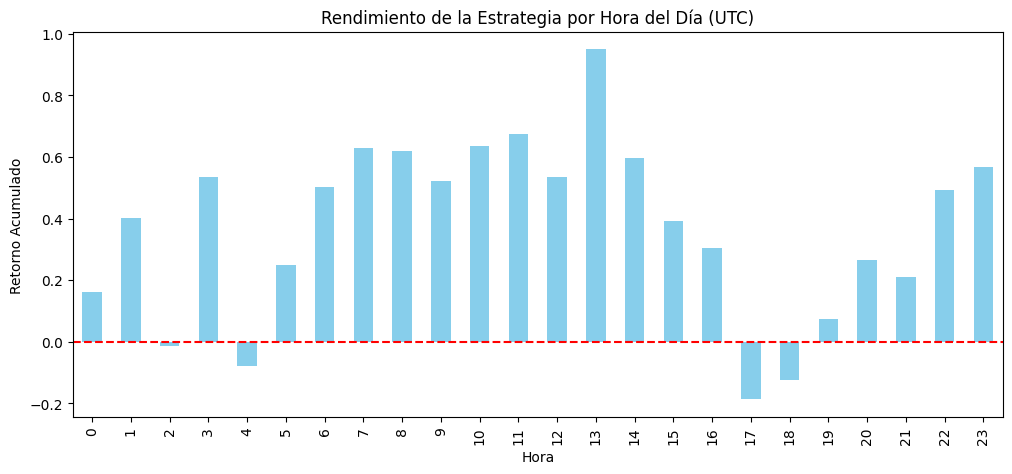

In [19]:
analyze_by_hour(result_triple)

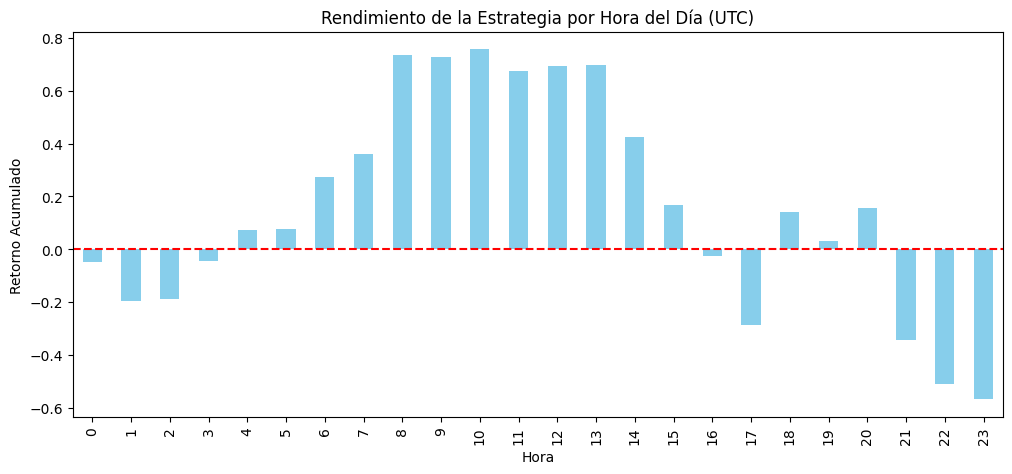

In [20]:
analyze_by_hour(result_torch)

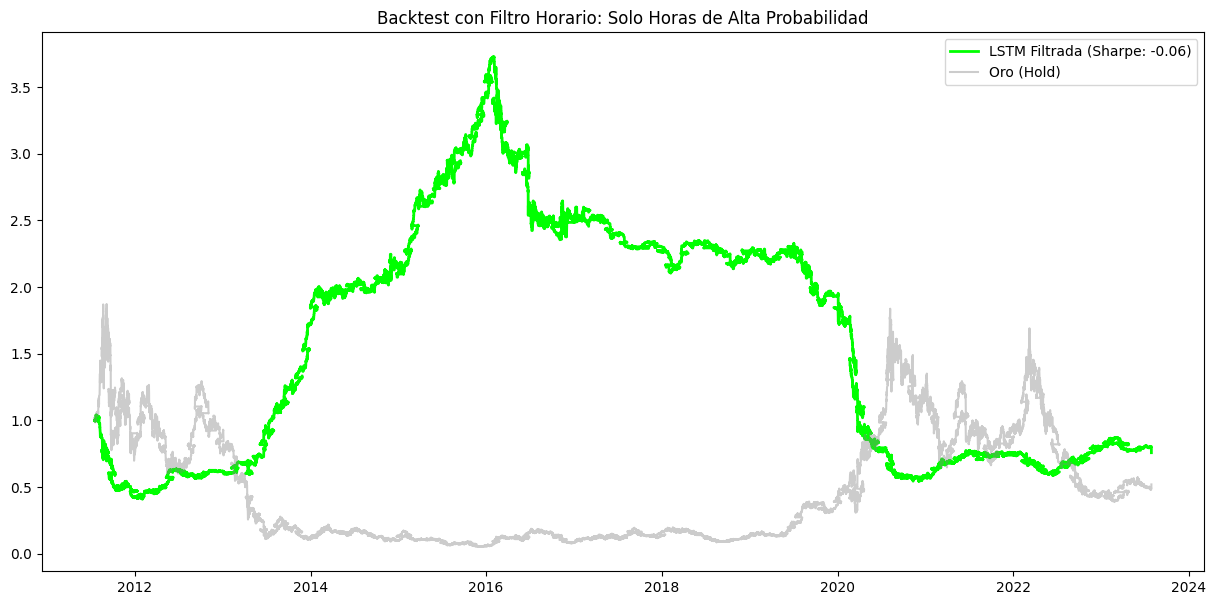

🚀 Sharpe Ratio con Filtro: -0.06


In [21]:
plot_backtest_filtrado(result_triple)

In [22]:
print(f"📊 El Sharpe Ratio REAL de este modelo es: {calculate_real_sharpe_binary(result_torch):.4f}")

✅ Análisis del Modelo Binario:
-------------------------------
💰 Retorno Acumulado Estrategia: 33.8851
📈 Retorno Acumulado Mercado:    0.5192
📊 El Sharpe Ratio REAL de este modelo es: 1.2874


In [23]:
calculate_sharpe_triple(result_triple)

📈 Resultado Final:
-------------------
💰 Sharpe Ratio: 2.2582
🚀 Retorno Total: 367864.39%
⚖️ Operaciones totales: 82899 de 133712


np.float64(2.2581588691014574)

In [24]:
calculate_final_binary_sharpe(result_torch)

📊 --- RESULTADOS BINARIOS ---
💰 Sharpe Ratio: 1.2874
📉 Volatilidad Anual: 27.75%
📈 Retorno Final: 33.8851
-------------------------------


np.float64(1.2873641565878773)

In [25]:
result_torch_filtered = apply_time_filter(result_torch) # Usa el df que tiene prob_up


🚀 Sharpe Original: 0.6245
💎 Sharpe Filtrado: 0.9247


In [26]:
stress_test_with_costs(result_torch_filtered, 0.0002)


🧪 --- STRESS TEST (1 TICK COST) ---
📉 Sharpe con Costes: -0.0024
💰 Retorno Final tras costes: 0.8032
🚪 Total de entradas pagadas: 10080
------------------------------------


np.float64(-0.0024124267457365195)

In [27]:
# Sobre el dataframe original de 3028 operaciones
avg_ret_per_trade = result_torch_filtered[result_torch_filtered['signal_final'] == 1]['ret_real'].mean()
print(f"Retorno medio por trade: {avg_ret_per_trade:.6f}")

Retorno medio por trade: 0.000053


In [ ]:
close_map = df_final_dict[f'{MINUTES}min'].set_index('datetime')['close']
result_torch_filtered['close'] = result_torch_filtered['datetime'].map(close_map)

In [33]:
result_triple['close'] = result_triple['datetime'].map(close_map)

In [29]:
run_backtest_pro(result_torch_filtered, tp_ticks=8, sl_ticks=4)

🏆 Resultado con Gestión de Riesgo (TP:8 / SL:4 ticks):
📊 Sharpe Neto: 7.8178
💰 Retorno Total: 7.4150


,datetime,actual,pred,prob_up,ret_real,strat_ret,cum_strat,cum_market,signal,hour,signal_final,strat_ret_filtered,close,strat_ret_managed
0,2011-07-18 04:00:00,1,1,0.605594,0.002130,0.002130,1.002130,1.002130,1,4,1,0.002130,1594.5,0.000439
1,2011-07-18 05:00:00,1,1,0.630598,0.001754,0.001754,1.003888,1.003888,1,5,1,0.001754,1594.6,0.000439
2,2011-07-18 06:00:00,1,1,0.614935,0.001628,0.001628,1.005522,1.005522,1,6,1,0.001628,1595.8,0.000439
3,2011-07-18 07:00:00,1,1,0.602117,0.000876,0.000876,1.006403,1.006403,1,7,1,0.000876,1597.9,0.000438
4,2011-07-18 08:00:00,1,1,0.573846,0.001564,0.001564,1.007977,1.007977,1,8,1,0.001564,1597.4,0.000438
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133707,2023-07-28 19:00:00,0,1,0.503233,-0.000817,-0.000817,31.993982,0.490243,1,19,0,-0.000000,1960.3,0.000000
133708,2023-07-28 20:00:00,0,1,0.525836,-0.000460,-0.000460,31.979280,0.490018,1,20,0,-0.000000,1959.0,0.000000
133709,2023-07-28 21:00:00,1,1,0.570617,0.020065,0.020065,32.620940,0.499850,1,21,1,0.020065,1958.8,0.000357
133710,2023-07-28 22:00:00,1,1,0.627106,0.018964,0.018964,33.239576,0.509329,1,22,0,0.000000,1958.7,0.000000


In [30]:
run_backtest_managed_with_costs(result_torch_filtered, tp_ticks=40, sl_ticks=20, cost_in_ticks=2, tick_val=0.0001)

✅ TP: 40 | SL: 20 | Coste: 2 ticks
📊 Sharpe Neto Final: 15.9759
💰 Retorno Acumulado: 1.0225


,datetime,actual,pred,prob_up,ret_real,strat_ret,cum_strat,cum_market,signal,hour,signal_final,strat_ret_filtered,close,strat_ret_managed
0,2011-07-18 04:00:00,1,1,0.605594,0.002130,0.002130,1.002130,1.002130,1,4,1,0.002130,1594.5,0.000002
1,2011-07-18 05:00:00,1,1,0.630598,0.001754,0.001754,1.003888,1.003888,1,5,1,0.001754,1594.6,0.000002
2,2011-07-18 06:00:00,1,1,0.614935,0.001628,0.001628,1.005522,1.005522,1,6,1,0.001628,1595.8,0.000002
3,2011-07-18 07:00:00,1,1,0.602117,0.000876,0.000876,1.006403,1.006403,1,7,1,0.000876,1597.9,0.000002
4,2011-07-18 08:00:00,1,1,0.573846,0.001564,0.001564,1.007977,1.007977,1,8,1,0.001564,1597.4,0.000002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133707,2023-07-28 19:00:00,0,1,0.503233,-0.000817,-0.000817,31.993982,0.490243,1,19,0,-0.000000,1960.3,0.000000
133708,2023-07-28 20:00:00,0,1,0.525836,-0.000460,-0.000460,31.979280,0.490018,1,20,0,-0.000000,1959.0,0.000000
133709,2023-07-28 21:00:00,1,1,0.570617,0.020065,0.020065,32.620940,0.499850,1,21,1,0.020065,1958.8,0.000002
133710,2023-07-28 22:00:00,1,1,0.627106,0.018964,0.018964,33.239576,0.509329,1,22,0,0.000000,1958.7,0.000000


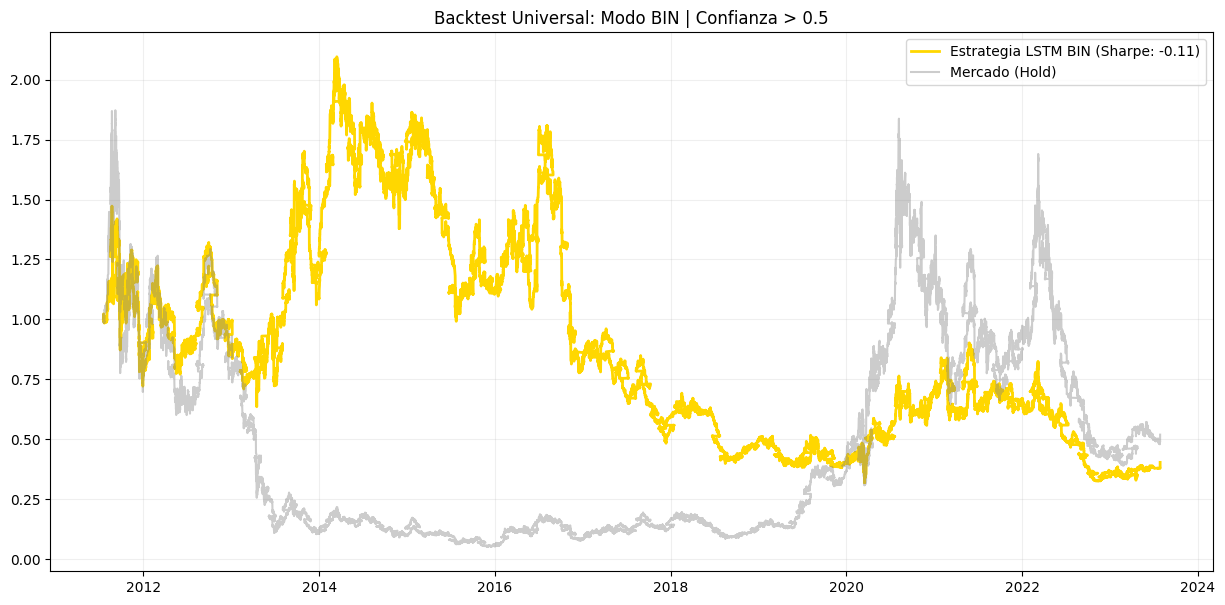

✅ Modo detectado: BIN
💰 Sharpe Ratio: -0.11
🎯 Win Rate: 49.07%


,datetime,actual,pred,prob_up,ret_real,strat_ret,cum_strat,cum_market,signal,hour,signal_final,strat_ret_filtered,close
0,2011-07-18 04:00:00,1,1,0.605594,0.002130,0.002067,1.002067,1.002130,1,4,1,0.002130,1594.5
1,2011-07-18 05:00:00,1,1,0.630598,0.001754,0.001692,1.003763,1.003888,1,5,1,0.001754,1594.6
2,2011-07-18 06:00:00,1,1,0.614935,0.001628,0.001565,1.005334,1.005522,1,6,1,0.001628,1595.8
3,2011-07-18 07:00:00,1,1,0.602117,0.000876,0.000813,1.006151,1.006403,1,7,1,0.000876,1597.9
4,2011-07-18 08:00:00,1,1,0.573846,0.001564,0.001501,1.007662,1.007977,1,8,1,0.001564,1597.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
133707,2023-07-28 19:00:00,0,1,0.503233,-0.000817,-0.000868,0.381225,0.490243,1,19,0,-0.000000,1960.3
133708,2023-07-28 20:00:00,0,1,0.525836,-0.000460,-0.000511,0.381030,0.490018,1,20,0,-0.000000,1959.0
133709,2023-07-28 21:00:00,1,1,0.570617,0.020065,0.020014,0.388656,0.499850,1,21,1,0.020065,1958.8
133710,2023-07-28 22:00:00,1,1,0.627106,0.018964,0.018913,0.396007,0.509329,1,22,0,0.000000,1958.7


In [31]:
plot_universal_backtest(result_torch_filtered)

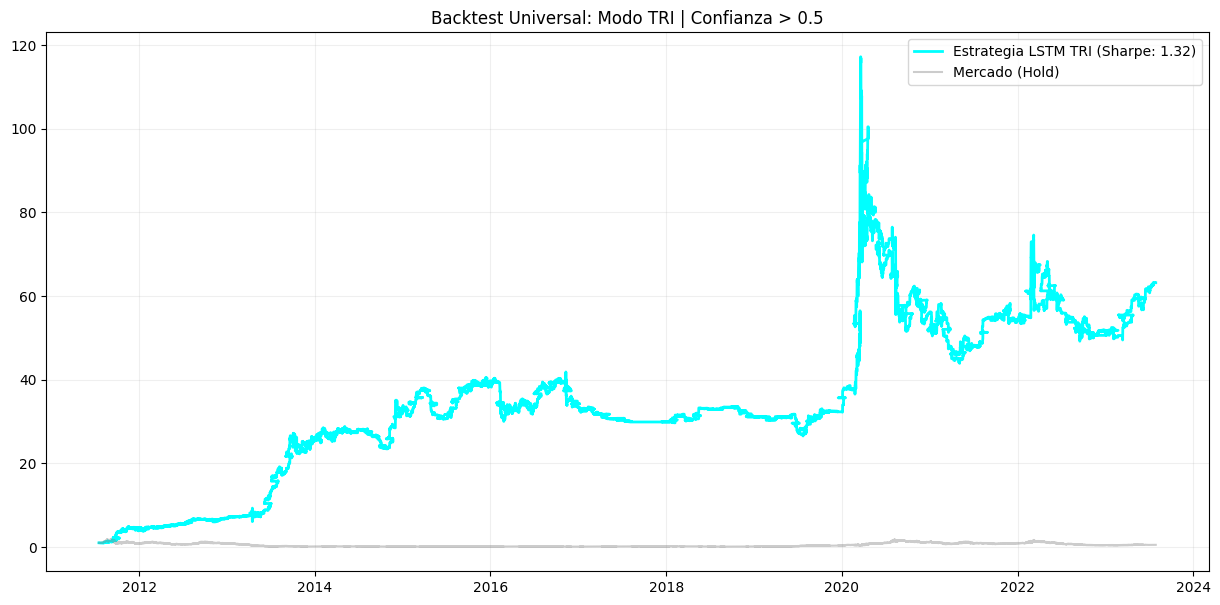

✅ Modo detectado: TRI
💰 Sharpe Ratio: 1.32
🎯 Win Rate: 52.66%


,datetime,actual,pred,prob_sell,prob_neutral,prob_buy,ret_real,close,signal,strat_ret,cum_strat,cum_market
0,2011-07-18 04:00:00,2,1,0.243226,0.460301,0.296473,0.002130,1594.5,0,0.0,1.000000,1.002130
1,2011-07-18 05:00:00,2,1,0.240879,0.445072,0.314049,0.001754,1594.6,0,0.0,1.000000,1.003888
2,2011-07-18 06:00:00,2,1,0.272804,0.404358,0.322838,0.001628,1595.8,0,0.0,1.000000,1.005522
3,2011-07-18 07:00:00,1,1,0.294130,0.384617,0.321253,0.000876,1597.9,0,0.0,1.000000,1.006403
4,2011-07-18 08:00:00,2,1,0.310271,0.367410,0.322320,0.001564,1597.4,0,0.0,1.000000,1.007977
...,...,...,...,...,...,...,...,...,...,...,...,...
133707,2023-07-28 19:00:00,1,2,0.388232,0.195632,0.416136,-0.000817,1960.3,0,-0.0,63.205513,0.490243
133708,2023-07-28 20:00:00,1,2,0.362487,0.202768,0.434746,-0.000460,1959.0,0,-0.0,63.205513,0.490018
133709,2023-07-28 21:00:00,2,2,0.333048,0.212014,0.454938,0.020065,1958.8,0,0.0,63.205513,0.499850
133710,2023-07-28 22:00:00,2,2,0.295610,0.219352,0.485038,0.018964,1958.7,0,0.0,63.205513,0.509329


In [34]:
plot_universal_backtest(result_triple)

In [31]:
import shap

def run_shap_analysis(model, train_loader, test_loader, feature_names):
    # 1. Preparar una muestra de datos (SHAP necesita tensores de fondo)
    # Tomamos el primer batch del train_loader como "background"
    batch_train_x, _ = next(iter(train_loader))
    batch_test_x, _ = next(iter(test_loader))
    
    # SHAP en PyTorch prefiere trabajar con tensores en CPU para la explicación
    model.cpu()
    background = batch_train_x[:100].cpu() # 100 ejemplos de fondo son suficientes
    test_samples = batch_test_x[:20].cpu()   # Explicamos las primeras 20 predicciones
    
    # 2. Inicializar el Explainer
    # DeepExplainer es ideal para redes neuronales
    explainer = shap.DeepExplainer(model, background)
    
    # 3. Calcular valores SHAP
    shap_values = explainer.shap_values(test_samples)
    
    # 4. Visualización
    print("📊 Generando Summary Plot...")
    # Como los datos son [batch, window, features], colapsamos el tiempo 
    # para ver la importancia general de la feature
    shap_values_collapsed = np.mean(np.abs(shap_values), axis=1) 
    
    shap.summary_plot(
        shap_values_collapsed, 
        features=test_samples.mean(dim=1).numpy(), 
        feature_names=feature_names,
        plot_type="bar"
    )

# Uso:
# run_shap_analysis(model_torch, train_loader, test_loader, feature_cols)

In [32]:
def explain_gold_model(model, df_test, feature_cols, lookback, scaler):
    # 1. Mover modelo a CPU y poner en modo entrenamiento (necesario para SHAP)
    model.cpu()
    model.train() 
    
    # Desactivamos capas que cambian el comportamiento en train
    for module in model.modules():
        if isinstance(module, (nn.Dropout, nn.BatchNorm1d)):
            module.eval()

    # 2. Preparación de datos (Directo en CPU)
    df_test_scaled = df_test.copy()
    df_test_scaled[feature_cols] = scaler.transform(df_test_scaled[feature_cols])
    
    X_test_shap, _ = create_lstm_dataset(df_test_scaled, feature_cols, target_col='target_bin', lookback=lookback)
    
    # Aseguramos tensores en CPU y Float32
    X_tensor = torch.tensor(X_test_shap, dtype=torch.float32).cpu()
    
    # 3. Muestras para el análisis
    # Usar 50 de fondo y 20 para explicar es suficiente para ver la tendencia
    background = X_tensor[:50] 
    test_samples = X_tensor[50:70] 
    
    # 4. Explicador SHAP
    # DeepExplainer funciona bien con LSTMs en CPU
    explainer = shap.DeepExplainer(model, background)
    
    # # 5. Cálculo de valores SHAP
    # print("⏳ Calculando valores SHAP (esto puede tardar un minuto en CPU)...")
    # shap_values = explainer.shap_values(test_samples, check_additivity=False)
    
    # # 6. Procesamiento de dimensiones
    # # SHAP devuelve una lista por salida. Para clasificación binaria, tomamos [0] o [1]
    # shap_val_array = np.array(shap_values)
    
    # # Si la forma es [muestras, tiempo, features], promediamos el tiempo
    # if len(shap_val_array.shape) == 4: # [outputs, samples, time, features]
    #     shap_val_avg = np.abs(shap_val_array[0]).mean(axis=1)
    # else: # [samples, time, features]
    #     shap_val_avg = np.abs(shap_val_array).mean(axis=1)

    # print("📊 SHAP Summary Plot:")
    # shap.summary_plot(
    #     shap_val_avg, 
    #     features=test_samples.mean(dim=1).numpy(), 
    #     feature_names=feature_cols,
    #     plot_type="bar" # Tipo barras para ver importancia clara
    # )
    # 5. Cálculo de valores SHAP
    shap_values = explainer.shap_values(test_samples, check_additivity=False)
    
    # 6. Normalización de dimensiones - VERSIÓN FINAL
    if isinstance(shap_values, list):
        # En clasificación binaria con DeepExplainer, a veces devuelve [muestras, tiempo, features, salidas]
        # Tomamos la salida 1
        shap_val_array = np.array(shap_values[-1]) 
    else:
        shap_val_array = np.array(shap_values)

    print(f"DEBUG: Shape original SHAP: {shap_val_array.shape}")

    # 7. Colapsar el Lookback (la dimensión del tiempo)
    # Si es (20, 24, 27) -> queremos (20, 27)
    if len(shap_val_array.shape) == 3:
        # Hacemos la media del impacto absoluto en las 24 horas
        shap_val_final = np.abs(shap_val_array).mean(axis=1)
    elif len(shap_val_array.shape) == 4:
        # Si viene con (muestras, tiempo, features, salida)
        shap_val_final = np.abs(shap_val_array).mean(axis=1)
        if len(shap_val_final.shape) == 3: # (muestras, features, 1)
            shap_val_final = shap_val_final.reshape(shap_val_final.shape[0], shap_val_final.shape[1])
    else:
        shap_val_final = shap_val_array

    # 8. Preparar X_plot coincidente (20, 27)
    # Colapsamos el tiempo de las muestras de entrada también para el gráfico
    if len(test_samples.shape) == 3:
        X_plot = test_samples.mean(dim=1).numpy()
    else:
        X_plot = test_samples.numpy()

    print(f"✅ Ajuste final: SHAP {shap_val_final.shape} | Features {X_plot.shape}")

    # 9. Generar el gráfico
    shap.summary_plot(
        shap_val_final, 
        features=X_plot, 
        feature_names=feature_cols,
        plot_type="bar"
    )
    # OPCIONAL: Devolver el modelo a la GPU si vas a seguir usándolo
    # model.cuda()

In [33]:
df_test_reciente = df_final_dict[f'{MINUTES}min'].tail(1000).copy()

c:\Users\LIJUN\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\explainers\_deep\deep_pytorch.py:255: UserWarning: unrecognized nn.Module: LSTM
  warnings.warn(f"unrecognized nn.Module: {module_type}")


DEBUG: Shape original SHAP: (20, 24, 27, 1)
✅ Ajuste final: SHAP (20, 27) | Features (20, 27)


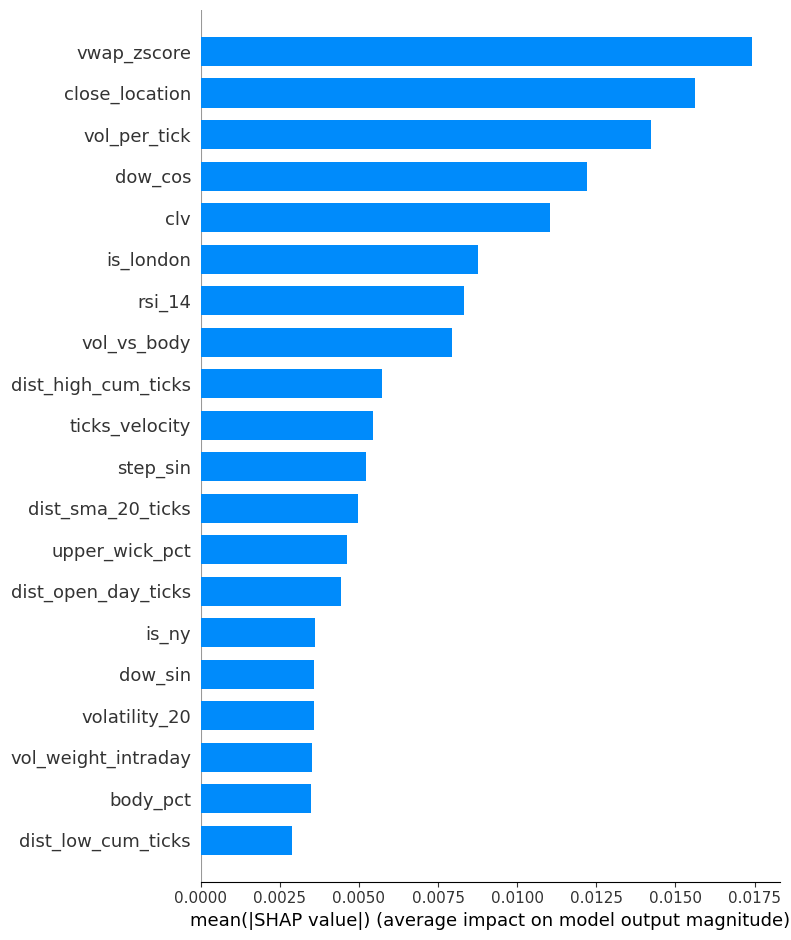

In [35]:
explain_gold_model(model, df_test_reciente, FEATURE_COLUMNS, 24, sc)

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

def sensitivity_scan(df_results, tp_range, sl_range, commission=1.0):
    """
    Prueba combinaciones de TP y SL para ver la estabilidad del Sharpe.
    """
    matrix_sharpe = np.zeros((len(sl_range), len(tp_range)))
    
    for i, sl in enumerate(sl_range):
        for j, tp in enumerate(tp_range):
            pnl = []
            for _, row in df_results.iterrows():
                # Simulamos la lógica de salida
                # Si predice 1 (Compra)
                if row['pred'] == 1:
                    if row['ret_real'] >= tp:
                        pnl.append(tp - commission)
                    elif row['ret_real'] <= -sl:
                        pnl.append(-sl - commission)
                    else:
                        pnl.append(row['ret_real'] - commission)
                # Si predice 0 (Venta/Nada según tu modelo)
                # Ajustar aquí si tu modelo es binario 0/1 o -1/1
            
            if len(pnl) > 0:
                mean_pnl = np.mean(pnl)
                std_pnl = np.std(pnl) if np.std(pnl) > 0 else 1
                # Sharpe anualizado simplificado
                sharpe = (mean_pnl / std_pnl) * np.sqrt(252 * 10) # Ajustar según frecuencia
                matrix_sharpe[i, j] = sharpe

    # Visualización
    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix_sharpe, annot=True, fmt=".2f", 
                xticklabels=tp_range, yticklabels=sl_range, cmap='RdYlGn')
    plt.title('Estabilidad del Sharpe: TP vs SL')
    plt.xlabel('Take Profit (Ticks)')
    plt.ylabel('Stop Loss (Ticks)')
    plt.show()

# --- EJECUCIÓN ---
# Probamos TPs de 5 a 15 y SLs de 2 a 8
tps = np.arange(5, 16, 1)
sls = np.arange(2, 9, 1)



In [ ]:
# sensitivity_scan(result_torch_filtered, tps, sls)

KeyboardInterrupt: 

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

def sensitivity_scan_optimized(df_results, tp_range, sl_range, commission=1.0):
    """
    Versión vectorizada y optimizada para el escaneo de TP/SL.
    """
    # Convertimos columnas a arrays de numpy para velocidad máxima
    # Solo filtramos donde hubo predicción de compra (pred == 1)
    df_trades = df_results[df_results['pred'] == 1]
    returns = df_trades['ret_real'].values
    
    matrix_sharpe = np.zeros((len(sl_range), len(tp_range)))
    
    # Pre-calculamos la raíz para anualizar
    annualization_factor = np.sqrt(252 * 10) # Ajustar según tu frecuencia real

    for i, sl in enumerate(sl_range):
        for j, tp in enumerate(tp_range):
            # Lógica vectorizada:
            # np.where(condicion, valor_si_true, valor_si_false)
            
            # 1. Si retorno >= TP, ganamos TP
            # 2. Si no, si retorno <= -SL, perdemos SL
            # 3. Si no, nos quedamos con el retorno real (salida por tiempo/cierre)
            pnl_vector = np.where(returns >= tp, tp, 
                         np.where(returns <= -sl, -sl, returns))
            
            # Restamos comisión a cada trade
            pnl_final = pnl_vector - commission
            
            if len(pnl_final) > 1:
                m = np.mean(pnl_final)
                s = np.std(pnl_final)
                if s > 0:
                    matrix_sharpe[i, j] = (m / s) * annualization_factor

    # Visualización (Idéntica a la anterior)
    plt.figure(figsize=(12, 9))
    sns.heatmap(matrix_sharpe, annot=True, fmt=".2f", 
                xticklabels=tp_range, yticklabels=sl_range, cmap='RdYlGn', center=0)
    plt.title('Mapa de Calor de Sharpe: Estabilidad TP vs SL')
    plt.xlabel('Take Profit (Ticks)')
    plt.ylabel('Stop Loss (Ticks)')
    plt.show()

# --- EJECUCIÓN ---
tps = np.arange(5, 16, 1)
sls = np.arange(2, 9, 1)



In [44]:
# Ajusta el tick_size según tu activo (GC=0.1, CL=0.01, 6B=0.0001, etc.)
tick_size = 0.1 

# Creamos una columna nueva en ticks
result_torch_filtered['ret_ticks'] = result_torch_filtered['ret_real'] / tick_size

In [45]:
def run_full_strategy_scan(df_results, tp_range, sl_range, commission=1.0):
    # Filtramos solo donde el modelo dio señal de entrada
    df_trades = df_results[df_results['pred'] == 1].copy()
    
    # IMPORTANTE: Usamos la columna en TICKS
    returns = df_trades['ret_ticks'].values 
    
    matrix_sharpe = np.zeros((len(sl_range), len(tp_range)))
    matrix_mdd = np.zeros((len(sl_range), len(tp_range)))
    
    annualization = np.sqrt(252 * 10)

    for i, sl in enumerate(sl_range):
        for j, tp in enumerate(tp_range):
            # Aplicamos TP y SL vectorizado
            pnl = np.where(returns >= tp, tp, 
                  np.where(returns <= -sl, -sl, returns))
            pnl_neto = pnl - commission
            
            if len(pnl_neto) > 1:
                # 1. Cálculo de Sharpe
                m, s = np.mean(pnl_neto), np.std(pnl_neto)
                matrix_sharpe[i, j] = (m / s) * annualization if s > 0 else 0
                
                # 2. Cálculo de Max Drawdown
                cum_pnl = np.cumsum(pnl_neto)
                peak = np.maximum.accumulate(cum_pnl)
                matrix_mdd[i, j] = np.max(peak - cum_pnl)

    # --- VISUALIZACIÓN DOBLE ---
    fig, ax = plt.subplots(1, 2, figsize=(20, 8))
    
    sns.heatmap(matrix_sharpe, annot=True, fmt=".2f", cmap='RdYlGn', ax=ax[0], xticklabels=tp_range, yticklabels=sl_range)
    ax[0].set_title('ESTABILIDAD DEL SHARPE (TICKS)')
    
    sns.heatmap(matrix_mdd, annot=True, fmt=".1f", cmap='Reds', ax=ax[1], xticklabels=tp_range, yticklabels=sl_range)
    ax[1].set_title('MAX DRAWDOWN (TICKS)')
    
    plt.show()

# --- EJECUCIÓN ---
# Asegúrate de haber creado 'ret_ticks' antes
# run_full_strategy_scan(df_results, np.arange(5, 16), np.arange(2, 9), commission=1.0)

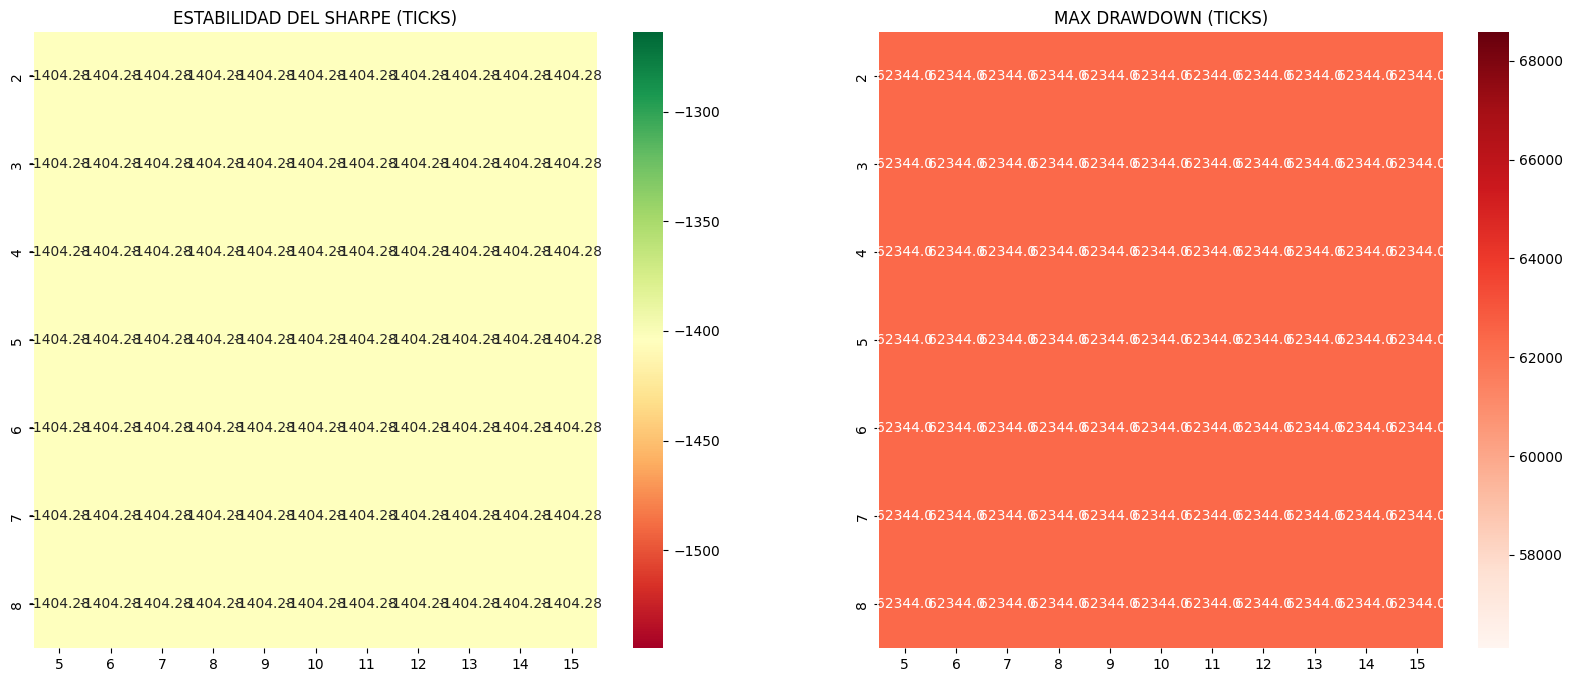

In [46]:
run_full_strategy_scan(result_torch_filtered, tps, sls)

In [47]:
def calculate_max_drawdown(pnl_array):
    """Calcula el máximo drawdown de una serie de PnL."""
    if len(pnl_array) == 0: return 0
    cumulative_pnl = np.cumsum(pnl_array)
    # Calculamos el pico máximo acumulado hasta cada punto
    peak = np.maximum.accumulate(cumulative_pnl)
    # El drawdown es la diferencia entre el pico y el valor actual
    # Si cumulative_pnl es mayor que el pico, el drawdown es 0
    drawdown = peak - cumulative_pnl
    return np.max(drawdown)

def sensitivity_scan_drawdown(df_results, tp_range, sl_range, commission=1.0):
    df_trades = df_results[df_results['pred'] == 1]
    returns = df_trades['ret_real'].values
    
    matrix_mdd = np.zeros((len(sl_range), len(tp_range)))
    
    for i, sl in enumerate(sl_range):
        for j, tp in enumerate(tp_range):
            # Lógica de TP/SL
            pnl_vector = np.where(returns >= tp, tp, 
                         np.where(returns <= -sl, -sl, returns))
            pnl_final = pnl_vector - commission
            
            # Calculamos el MDD para esta combinación
            matrix_mdd[i, j] = calculate_max_drawdown(pnl_final)

    # Visualización
    plt.figure(figsize=(12, 9))
    sns.heatmap(matrix_mdd, annot=True, fmt=".1f", 
                xticklabels=tp_range, yticklabels=sl_range, cmap='Reds')
    plt.title('Máximo Drawdown (en Ticks) por combinación TP/SL')
    plt.xlabel('Take Profit (Ticks)')
    plt.ylabel('Stop Loss (Ticks)')
    plt.show()

# --- EJECUCIÓN ---


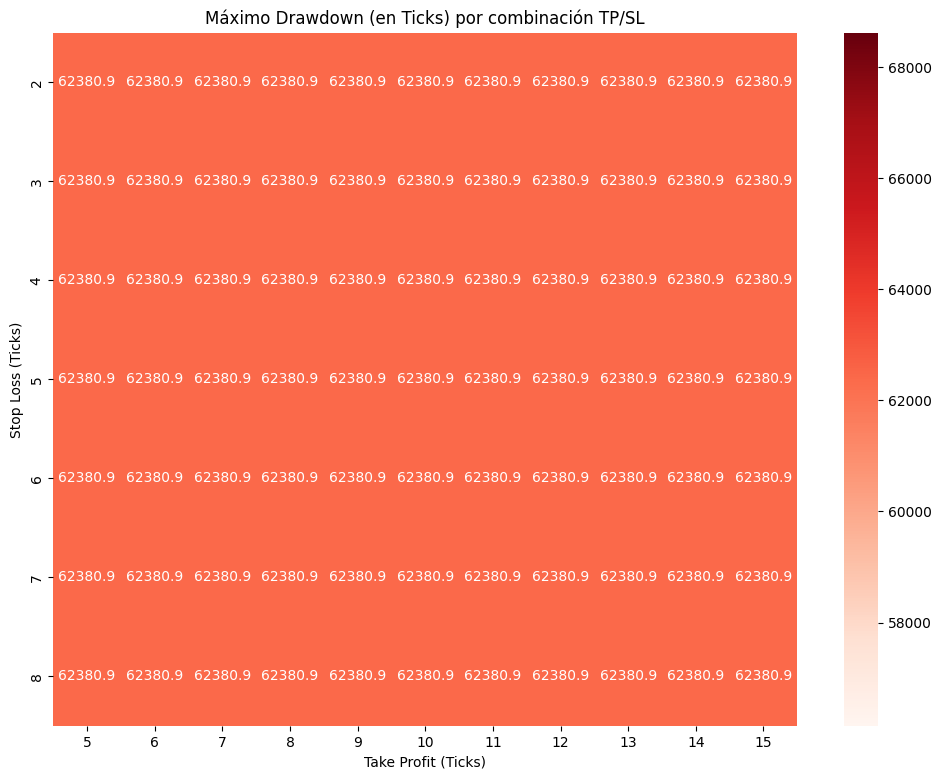

In [48]:
sensitivity_scan_drawdown(result_torch_filtered, tps, sls, commission=1.0)

In [49]:
print(f"Media de ret_ticks: {result_torch_filtered['ret_ticks'].mean()}")
print(f"Máximo de ret_ticks: {result_torch_filtered['ret_ticks'].max()}")
print(f"Mínimo de ret_ticks: {result_torch_filtered['ret_ticks'].min()}")

Media de ret_ticks: 1.2825207283023132e-05
Máximo de ret_ticks: 0.5492654790857213
Mínimo de ret_ticks: -0.5286051592192921


In [50]:
def monte_carlo_simulation(pnl_vector, iterations=1000, capital_inicial=1000):
    plt.figure(figsize=(10, 6))
    final_returns = []
    
    for _ in range(iterations):
        # Desordenamos los trades (muestreo con reemplazo)
        simulated_pnl = np.random.choice(pnl_vector, size=len(pnl_vector), replace=True)
        equity_curve = capital_inicial + np.cumsum(simulated_pnl)
        plt.plot(equity_curve, color='blue', alpha=0.01) # Curvas tenues
        final_returns.append(equity_curve[-1])
    
    plt.title(f"Simulación Monte Carlo ({iterations} caminos)")
    plt.xlabel("Número de Trades")
    plt.ylabel("Capital")
    plt.axhline(capital_inicial, color='red', linestyle='--')
    plt.show()
    
    print(f"Probabilidad de terminar en positivo: {(np.array(final_returns) > capital_inicial).mean() * 100}%")

# Uso:
# pnl_final = np.where(returns >= 8, 8, np.where(returns <= -4, -4, returns)) - 1.0
# monte_carlo_simulation(pnl_final)

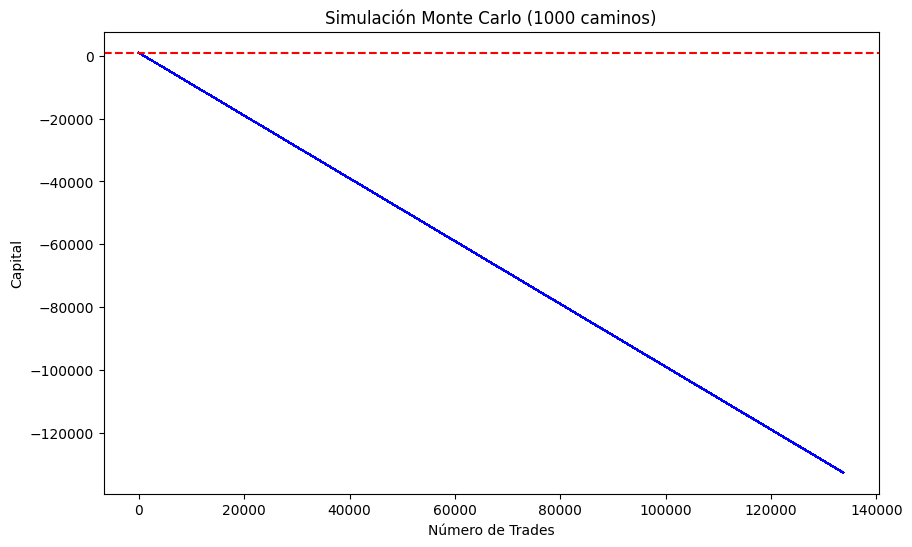

Probabilidad de terminar en positivo: 0.0%


In [51]:
pnl_final = np.where(result_torch_filtered['ret_ticks'] >= 8, 8, np.where(result_torch_filtered['ret_ticks'] <= -4, -4, result_torch_filtered['ret_ticks'])) - 1.0
monte_carlo_simulation(pnl_final)